# NLU Assignment 2: Word Embeddings & Character-Level RNNs

## Problem 1: Learning Word Embeddings from IIT Jodhpur Data
## Problem 2: Character-Level Name Generation Using Recurrent Neural Networks

## Setup and Imports

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
import io
import importlib
import importlib.util
from collections import Counter, defaultdict
from wordcloud import WordCloud
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from urllib.parse import urljoin
import requests
from bs4 import BeautifulSoup
from scipy.spatial.distance import cosine

_pypdf_spec = importlib.util.find_spec("pypdf")
if _pypdf_spec is not None:
    PdfReader = importlib.import_module("pypdf").PdfReader
else:
    PdfReader = None

In [62]:


# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Create directories
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Setup matplotlib
rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-darkgrid')

print("Imports successful. Device:", 'cuda' if torch.cuda.is_available() else 'cpu')

Imports successful. Device: cpu


---
# PROBLEM 1: WORD EMBEDDINGS FROM IIT JODHPUR DATA
---

## Task 1: Data Collection and Preprocessing

In [5]:
"""Task 1.1: Web Scraping IIT Jodhpur Website"""

FACULTY_LISTING_URLS = [
    # DEPARTMENTS (11)
    ("faculty", "BB",   "https://www.iitj.ac.in/People/List?dept=bioscience-bioengineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "CHE",  "https://www.iitj.ac.in/People/List?dept=chemical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "CH",   "https://www.iitj.ac.in/People/List?dept=Chemistry&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "CE",   "https://www.iitj.ac.in/People/List?dept=civil-and-infrastructure-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "CSE",  "https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "EE",   "https://www.iitj.ac.in/People/List?dept=electrical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "HSS",  "https://www.iitj.ac.in/People/List?dept=humanities-and-social-sciences&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "MME",  "https://www.iitj.ac.in/People/List?dept=materials-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "MA",   "https://www.iitj.ac.in/People/List?dept=mathematics&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "ME",   "https://www.iitj.ac.in/People/List?dept=Mechanical-Engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "PH",   "https://www.iitj.ac.in/People/List?dept=physics&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),

    # SCHOOLS (4)
    ("faculty", "SAIDE", "https://www.iitj.ac.in/People/List?dept=school-of-artificial-intelligence-data-science&c=ce26246f-00c9-4286-bb4c-7f023b4c5460"),
    ("faculty", "SME",   "https://www.iitj.ac.in/People/List?dept=schools&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "SOD",   "https://www.iitj.ac.in/People/List?dept=school-of-design&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
    ("faculty", "SOLA",  "https://www.iitj.ac.in/People/List?dept=school-of-liberal-arts&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd"),
]

URL_CATALOGUE = [
    # MANDATORY DOCUMENTS (High-priority for Task-1)
    ("pdf_regulation", "UG_PG_Ordinance", "https://iitj.ac.in/PageImages/Gallery/02-2025/ACADEMIC-PROGRAMMES-638755723291553278.pdf"),
    ("academics", "academic_home", "https://iitj.ac.in/office-of-academics/en/academics"),
    ("news", "announcements", "https://www.iitj.ac.in/main/en/all-announcement"),

    # DEPARTMENTS (10)
    ("dept", "BB", "https://www.iitj.ac.in/bioscience-bioengineering"),
    ("dept", "CH", "https://www.iitj.ac.in/chemistry"),
    ("dept", "CHE", "https://www.iitj.ac.in/chemical-engineering"),
    ("dept", "CE", "https://www.iitj.ac.in/civil-infrastructure-engineering"),
    ("dept", "CSE", "https://www.iitj.ac.in/computer-science-engineering"),
    ("dept", "EE", "https://www.iitj.ac.in/electrical-engineering"),
    ("dept", "MA", "https://www.iitj.ac.in/mathematics"),
    ("dept", "ME", "https://www.iitj.ac.in/mechanical-engineering"),
    ("dept", "MME", "https://www.iitj.ac.in/materials-engineering"),
    ("dept", "PH", "https://www.iitj.ac.in/physics"),

    # SCHOOLS (4)
    ("school", "SAIDE", "https://www.iitj.ac.in/school-of-artificial-intelligence-data-science/en/ai-and-ds-ecosystem"),
    ("school", "SOD", "https://www.iitj.ac.in/school-of-design"),
    ("school", "SOLA", "https://www.iitj.ac.in/school-of-liberal-arts"),
    ("school", "SME", "https://www.iitj.ac.in/schools/en/School-of-Management-&-Entrepreneurship"),

    # CENTRES (7)
    ("centre", "CET", "https://www.iitj.ac.in/cete"),
    ("centre", "CETSD", "https://www.iitj.ac.in/cetsd"),
    ("centre", "CRF", "https://www.iitj.ac.in/crf"),
    ("centre", "CTFP", "https://iitj.ac.in/center-for-technology-foresight-and-policy/en/about-us"),
    ("centre", "MCOENSSR", "https://iitj.ac.in/manekshaw-centre/en/Manekshaw-Centre"),
    ("centre", "MedicalTech", "https://iitj.ac.in/medical-technologies/en/medical-technologies"),
    ("centre", "RCRICE", "https://www.iitj.ac.in/rcrice"),

    # IDRPs / IDRCs (6)
    ("idrp", "AIoT", "https://iitj.ac.in/iot"),
    ("idrp", "DigitalHealth", "https://www.iitj.ac.in/cdh"),
    ("idrp", "DigitalHumanities", "https://www.iitj.ac.in/dh"),
    ("idrp", "Quantum", "https://www.iitj.ac.in/qic"),
    ("idrp", "Robotics", "https://www.iitj.ac.in/rm"),
    ("idrp", "SpaceScience", "https://www.iitj.ac.in/sst"),
]

NOTICE_INDEX_URLS = [
    "https://www.iitj.ac.in/main/en/all-announcement",
    "https://www.iitj.ac.in/main/en/news",
]

def scrape_iitj(max_depth=1, max_urls=80):
    """Scrape IIT Jodhpur website to build corpus"""
    seed_urls = [url for _, _, url in URL_CATALOGUE]
    seed_urls.extend(url for _, _, url in FACULTY_LISTING_URLS)
    seed_urls.extend(NOTICE_INDEX_URLS)
    base_urls = list(dict.fromkeys(seed_urls))
    
    visited_urls = set()
    scraped_text = []
    
    def extract_text(text):
        """Clean whitespace"""
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def extract_pdf_text(pdf_bytes):
        """Extract text from PDF bytes if pypdf is available"""
        if PdfReader is None:
            return ""
        try:
            reader = PdfReader(io.BytesIO(pdf_bytes))
            pages = [(page.extract_text() or "") for page in reader.pages]
            return extract_text(" ".join(pages))
        except Exception:
            return ""
    
    def scrape_url(url, depth=0):
        """Recursively scrape from URL"""
        if depth > max_depth or url in visited_urls or len(visited_urls) >= max_urls:
            return
        visited_urls.add(url)
        
        try:
            response = requests.get(url, timeout=12)
            if response.status_code != 200:
                return

            content_type = response.headers.get('Content-Type', '').lower()
            if url.lower().endswith('.pdf') or 'application/pdf' in content_type:
                pdf_text = extract_pdf_text(response.content)
                if pdf_text:
                    scraped_text.append(pdf_text)
                elif PdfReader is None:
                    print("  pypdf not installed; skipping PDF text extraction")
                return

            soup = BeautifulSoup(response.content, 'html.parser')
            
            # Remove script and style tags
            for script in soup(["script", "style", "noscript"]):
                script.decompose()
            
            # Extract text
            text = soup.get_text(separator=' ')
            cleaned = extract_text(text)
            if cleaned:
                scraped_text.append(cleaned)
            
            # Recursive scraping
            if depth < max_depth:
                for link in soup.find_all('a', href=True):
                    href = link['href']
                    full_url = urljoin(url, href)
                    if "iitj.ac.in" in full_url:
                        scrape_url(full_url, depth + 1)
        except Exception as e:
            print(f"  Error scraping {url}: {e}")
    
    print("Starting web scraping from IIT Jodhpur...")
    for base_url in base_urls:
        if len(visited_urls) >= max_urls:
            break
        print(f"  Scraping {base_url}...")
        scrape_url(base_url, depth=0)
    
    return "\n".join(scraped_text)

# Load raw corpus (use existing if available, otherwise scrape)
if os.path.exists('data/raw_corpus.txt'):
    with open('data/raw_corpus.txt', 'r', encoding='utf-8') as f:
        raw_text = f.read()
    print(f"Loaded existing raw corpus ({len(raw_text)} characters)")
else:
    raw_text = scrape_iitj(max_depth=1, max_urls=80)
    with open('data/raw_corpus.txt', 'w', encoding='utf-8') as f:
        f.write(raw_text)
    print(f"Scraped and saved raw corpus ({len(raw_text)} characters)")

Loaded existing raw corpus (633384 characters)


In [6]:
"""Task 1.2: Text Preprocessing and Statistics"""

def preprocess_text(text):
    """Preprocess text: remove boilerplate/noise, normalize, and deduplicate"""
    raw_docs = [doc.strip() for doc in text.split('\n') if doc.strip()]
    seen_docs = set()
    clean_docs = []

    # Common website/navigation words that add little semantic value
    noisy_tokens = {
        'skip', 'navigation', 'menu', 'toggle', 'cookie', 'cookies',
        'privacy', 'policy', 'terms', 'conditions', 'sitemap', 'copyright',
        'reserved', 'login', 'logout', 'search', 'contact', 'feedback',
        'disclaimer', 'main', 'page'
    }

    for doc in raw_docs:
        doc = doc.lower()

        # Remove URLs, emails, and date patterns first
        doc = re.sub(r'http\S+|www\S+', ' ', doc)
        doc = re.sub(r'\S+@\S+', ' ', doc)
        doc = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', ' ', doc)
        doc = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' ', doc)

        # Remove common boilerplate chunks
        doc = re.sub(r'(all rights reserved|office of|quick links|useful links)', ' ', doc)

        # Keep only alphabetic text and spaces
        doc = re.sub(r'[^a-z\s]', ' ', doc)
        doc = re.sub(r'\s+', ' ', doc).strip()

        if not doc:
            continue

        tokens = [t for t in doc.split() if t not in noisy_tokens]
        if len(tokens) < 8:
            # Drop very short fragments that are usually menu/footer leftovers
            continue

        cleaned_doc = ' '.join(tokens)
        if cleaned_doc not in seen_docs:
            seen_docs.add(cleaned_doc)
            clean_docs.append(cleaned_doc)

    return ' '.join(clean_docs), clean_docs

# Preprocess
clean_text, clean_docs = preprocess_text(raw_text)
tokens = clean_text.split()
filtered_text = clean_text

# Compute statistics
doc_count = len(clean_docs)
token_count = len(tokens)
vocab = set(tokens)
vocab_size = len(vocab)
word_counts = Counter(tokens)
avg_tokens_per_doc = token_count / max(1, doc_count)
type_token_ratio = vocab_size / max(1, token_count)

print("\n=== DATASET STATISTICS ===")
print(f"Total Documents: {doc_count}")
print(f"Total Tokens: {token_count}")
print(f"Vocabulary Size: {vocab_size}")
print(f"Average Tokens per Document: {avg_tokens_per_doc:.2f}")
print(f"Type-Token Ratio: {type_token_ratio:.4f}")
print(f"Most Common Words: {word_counts.most_common(10)}")

# Save clean corpus
with open('data/clean_corpus.txt', 'w', encoding='utf-8') as f:
    f.write(filtered_text)
print("\nClean corpus saved to data/clean_corpus.txt")


=== DATASET STATISTICS ===
Total Documents: 71
Total Tokens: 70637
Vocabulary Size: 4863
Average Tokens per Document: 994.89
Type-Token Ratio: 0.0688
Most Common Words: [('the', 2968), ('of', 2432), ('and', 1530), ('for', 1376), ('department', 1316), ('a', 1313), ('to', 1273), ('in', 1137), ('engineering', 729), ('tech', 725)]

Clean corpus saved to data/clean_corpus.txt


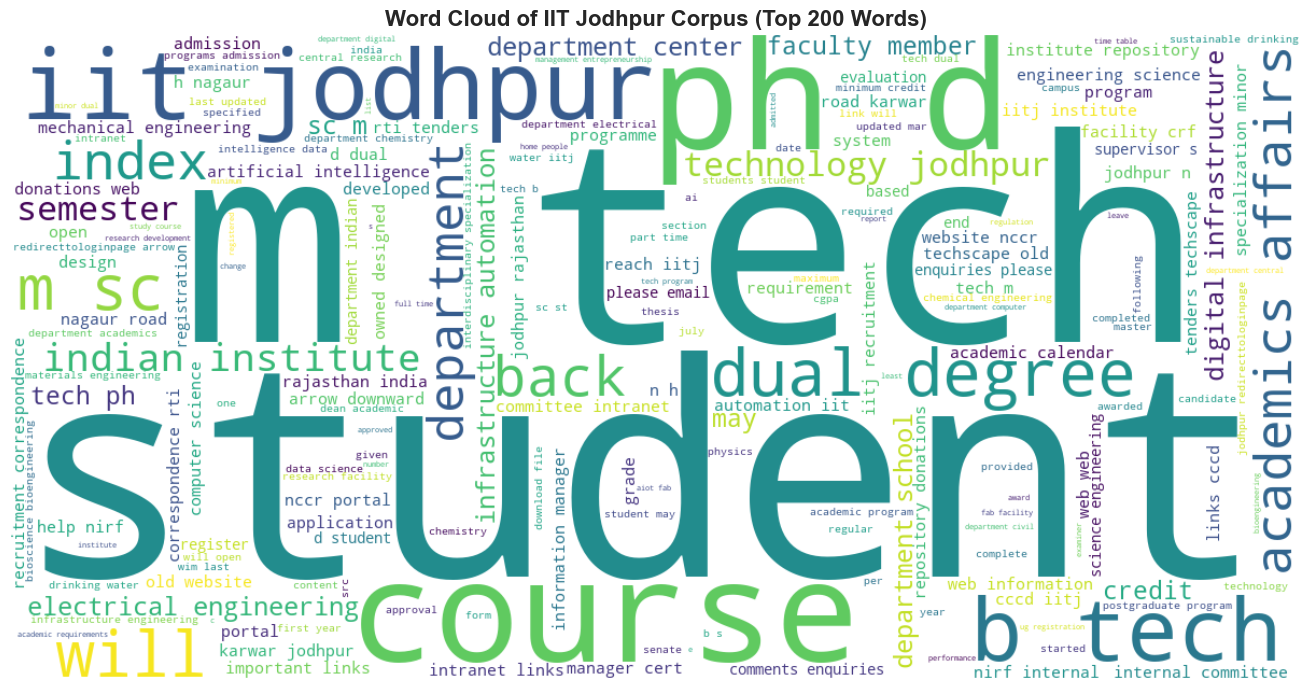

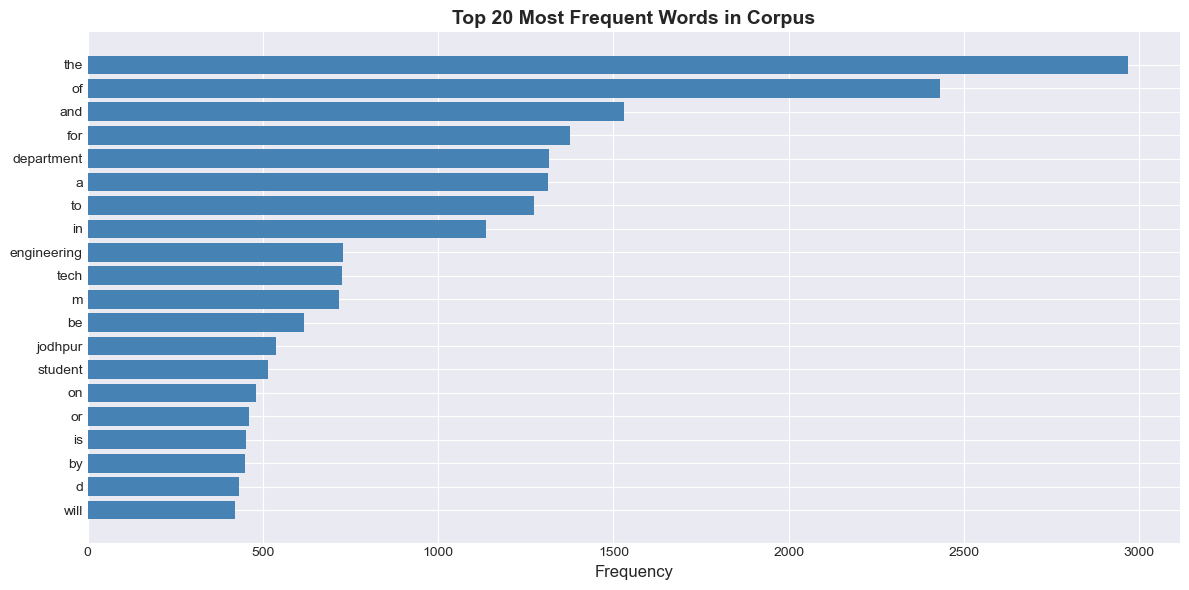

In [102]:
"""Task 1.3: Word Cloud Visualization"""

if token_count > 100:
    # Generate wordcloud
    wordcloud = WordCloud(width=1200, height=600, background_color='white', 
                          colormap='viridis', max_words=200).generate(filtered_text)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud of IIT Jodhpur Corpus (Top 200 Words)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Top 20 words frequency chart
    top_20_words = word_counts.most_common(20)
    words, freqs = zip(*top_20_words)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(words, freqs, color='steelblue')
    ax.set_xlabel('Frequency', fontsize=12)
    ax.set_title('Top 20 Most Frequent Words in Corpus', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('results/top_words_frequency.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Corpus too small for wordcloud visualization")

## Task 2: Word2Vec Models - Dataset Preparation

In [7]:
"""Task 2.1: Create vocabulary and Word2Vec Dataset"""

# Create vocabulary mappings
vocab_list = list(word_counts.keys())
word_to_idx = {word: idx for idx, word in enumerate(vocab_list)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}
V = len(vocab_list)  # Vocabulary size

print(f"Vocabulary size: {V} words")

def get_negative_samples(target_idx, num_samples, vocab_size):
    """Generate uniform random negative samples (different from target)"""
    neg_samples = []
    while len(neg_samples) < num_samples:
        sample = random.randint(0, vocab_size - 1)
        if sample != target_idx and sample not in neg_samples:
            neg_samples.append(sample)
    return neg_samples

class Word2VecDataset(Dataset):
    """Custom PyTorch dataset for Word2Vec (CBOW and Skip-gram)"""
    
    def __init__(self, text_tokens, word_to_idx, window_size=2, model_type="cbow", num_neg_samples=5):
        """
        Args:
            text_tokens: List of word tokens
            word_to_idx: Dictionary mapping words to indices
            window_size: Size of context window
            model_type: "cbow" or "skipgram"
            num_neg_samples: Number of negative samples (for skip-gram with negative sampling)
        """
        self.data = []
        self.model_type = model_type
        self.num_neg_samples = num_neg_samples
        self.vocab_size = len(word_to_idx)
        
        # Build context-target pairs
        for i in range(window_size, len(text_tokens) - window_size):
            # Context: words before and after target
            context_words = (text_tokens[i - window_size: i] + 
                            text_tokens[i + 1: i + window_size + 1])
            target_word = text_tokens[i]
            
            context_indices = [word_to_idx[w] for w in context_words]
            target_idx = word_to_idx[target_word]
            
            if model_type == "cbow":
                # CBOW: (context_words) -> target_word
                self.data.append((context_indices, target_idx))
            elif model_type == "skipgram":
                # Skip-gram: target_word -> context_words
                for context_idx in context_indices:
                    self.data.append((target_idx, context_idx))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        if self.model_type == "cbow":
            context, target = self.data[idx]
            return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)
        else:  # skipgram
            center, context = self.data[idx]
            neg_samples = get_negative_samples(context, self.num_neg_samples, self.vocab_size)
            return (torch.tensor(center, dtype=torch.long), 
                    torch.tensor(context, dtype=torch.long),
                    torch.tensor(neg_samples, dtype=torch.long))

print("\nDataset class created. Ready for model training.")

Vocabulary size: 4863 words

Dataset class created. Ready for model training.


## Task 2: Model Training with Hyperparameter Experiments

In [8]:
"""Task 2.2: CBOW Model Implementation"""

class CBOWModel(nn.Module):
    """Continuous Bag of Words (CBOW) model for learning word embeddings"""
    
    def __init__(self, vocab_size, embedding_dim):
        """
        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of word embeddings
        """
        super(CBOWModel, self).__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Word embedding layer
        self.embeddings = nn.Embedding(num_embeddings=vocab_size, 
                                       embedding_dim=embedding_dim)
        
        # Output layer
        self.linear = nn.Linear(in_features=embedding_dim, 
                               out_features=vocab_size)
    
    def forward(self, context_indices):
        """
        Forward pass
        Args:
            context_indices: Tensor of shape (batch_size, context_size) with word indices
        Returns:
            logits: Tensor of shape (batch_size, vocab_size)
        """
        # Get embeddings for context words
        embeds = self.embeddings(context_indices)  # (batch, context_size, embed_dim)
        
        # Average embeddings
        context_embed = embeds.mean(dim=1)  # (batch, embed_dim)
        
        # Output logits
        logits = self.linear(context_embed)  # (batch, vocab_size)
        
        return logits
    
    def get_embeddings(self):
        """Return learned embeddings"""
        return self.embeddings.weight.data

def train_cbow(embedding_dims, window_sizes, learning_rates, epochs=8, batch_size=128, max_batches_per_epoch=None):
    """Train CBOW model with hyperparameter experiments"""
    
    results = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for embed_dim in embedding_dims:
        for window_size in window_sizes:
            for lr in learning_rates:
                print(f"\nTraining CBOW: embed_dim={embed_dim}, window_size={window_size}, lr={lr}")
                
                # Create dataset and dataloader
                dataset = Word2VecDataset(tokens, word_to_idx, window_size=window_size, model_type="cbow")
                dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
                
                # Initialize model
                model = CBOWModel(V, embed_dim).to(device)
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.Adam(model.parameters(), lr=lr)
                
                # Training loop
                epoch_losses = []
                for epoch in range(epochs):
                    total_loss = 0.0
                    steps = 0
                    for context, target in dataloader:
                        context, target = context.to(device), target.to(device)
                        
                        optimizer.zero_grad()
                        logits = model(context)
                        loss = criterion(logits, target)
                        loss.backward()
                        optimizer.step()
                        
                        total_loss += loss.item()
                        steps += 1
                        if max_batches_per_epoch is not None and steps >= max_batches_per_epoch:
                            break
                    
                    avg_loss = total_loss / max(1, steps)
                    epoch_losses.append(avg_loss)
                    
                    if (epoch + 1) % 2 == 0 or epoch == 0:
                        print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
                
                # Store results
                result = {
                    'model_type': 'CBOW',
                    'embed_dim': embed_dim,
                    'window_size': window_size,
                    'learning_rate': lr,
                    'final_loss': epoch_losses[-1],
                    'model': model,
                    'losses': epoch_losses,
                    'num_params': sum(p.numel() for p in model.parameters())
                }
                results.append(result)
    
    return results

print("CBOW model class defined. Training function ready.")

CBOW model class defined. Training function ready.


In [71]:
"""Task 2.2: Train CBOW Models with Hyperparameter Experiments"""

QUICK_MODE = False

if QUICK_MODE:
    CBOW_EMBEDDING_DIMS = [50, 100]
    CBOW_WINDOW_SIZES = [2, 5]
    CBOW_LEARNING_RATES = [0.01]
    CBOW_EPOCHS = 6
    CBOW_MAX_BATCHES_PER_EPOCH = 150
else:
    CBOW_EMBEDDING_DIMS = [50, 100, 200]
    CBOW_WINDOW_SIZES = [2, 5]
    CBOW_LEARNING_RATES = [0.001, 0.01]
    CBOW_EPOCHS = 15
    CBOW_MAX_BATCHES_PER_EPOCH = None

print("Training CBOW models with hyperparameter experiments...")
cbow_results = train_cbow(
    embedding_dims=CBOW_EMBEDDING_DIMS,
    window_sizes=CBOW_WINDOW_SIZES,
    learning_rates=CBOW_LEARNING_RATES,
    epochs=CBOW_EPOCHS,
    batch_size=128,
    max_batches_per_epoch=CBOW_MAX_BATCHES_PER_EPOCH
)

print(f"\nCompleted training {len(cbow_results)} CBOW model(s)")

Training CBOW models with hyperparameter experiments...

Training CBOW: embed_dim=50, window_size=2, lr=0.001
  Epoch 1/15, Loss: 7.1895
  Epoch 2/15, Loss: 5.4625
  Epoch 4/15, Loss: 4.3502
  Epoch 6/15, Loss: 3.7769
  Epoch 8/15, Loss: 3.3793
  Epoch 10/15, Loss: 3.0706
  Epoch 12/15, Loss: 2.8173
  Epoch 14/15, Loss: 2.6026

Training CBOW: embed_dim=50, window_size=2, lr=0.01
  Epoch 1/15, Loss: 4.8959
  Epoch 2/15, Loss: 3.1828
  Epoch 4/15, Loss: 1.9203
  Epoch 6/15, Loss: 1.3317
  Epoch 8/15, Loss: 1.0431
  Epoch 10/15, Loss: 0.8780
  Epoch 12/15, Loss: 0.7732
  Epoch 14/15, Loss: 0.7003

Training CBOW: embed_dim=50, window_size=5, lr=0.001
  Epoch 1/15, Loss: 7.0396
  Epoch 2/15, Loss: 5.6938
  Epoch 4/15, Loss: 4.8601
  Epoch 6/15, Loss: 4.3910
  Epoch 8/15, Loss: 4.0355
  Epoch 10/15, Loss: 3.7443
  Epoch 12/15, Loss: 3.5001
  Epoch 14/15, Loss: 3.2895

Training CBOW: embed_dim=50, window_size=5, lr=0.01
  Epoch 1/15, Loss: 5.3058
  Epoch 2/15, Loss: 3.7451
  Epoch 4/15, Loss:

In [9]:
"""Task 2.3: Skip-gram Model with Negative Sampling"""

class SkipgramModel(nn.Module):
    """Skip-gram model with negative sampling for learning word embeddings"""
    
    def __init__(self, vocab_size, embedding_dim):
        """
        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of word embeddings
        """
        super(SkipgramModel, self).__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Target word embeddings (input embeddings)
        self.target_embeddings = nn.Embedding(num_embeddings=vocab_size, 
                                             embedding_dim=embedding_dim)
        
        # Context word embeddings (output embeddings)
        self.context_embeddings = nn.Embedding(num_embeddings=vocab_size, 
                                              embedding_dim=embedding_dim)
    
    def forward_positive(self, target_idx, context_idx):
        """
        Forward pass for positive samples (target, context) pairs
        Args:
            target_idx: Tensor of shape (batch_size,) with target word indices
            context_idx: Tensor of shape (batch_size,) with context word indices
        Returns:
            similarity: Tensor of shape (batch_size,) - dot products
        """
        target_embed = self.target_embeddings(target_idx)  # (batch, embed_dim)
        context_embed = self.context_embeddings(context_idx)  # (batch, embed_dim)
        
        # Dot product similarity
        similarity = (target_embed * context_embed).sum(dim=1)  # (batch,)
        
        return similarity
    
    def forward_negative(self, target_idx, negative_indices):
        """
        Forward pass for negative samples
        Args:
            target_idx: Tensor of shape (batch_size,) with target word indices
            negative_indices: Tensor of shape (batch_size, num_neg_samples) with negative word indices
        Returns:
            similarity: Tensor of shape (batch_size, num_neg_samples) - dot products
        """
        target_embed = self.target_embeddings(target_idx)  # (batch, embed_dim)
        negative_embed = self.context_embeddings(negative_indices)  # (batch, num_neg, embed_dim)
        
        # Batched dot product
        similarity = torch.bmm(negative_embed, target_embed.unsqueeze(2)).squeeze(2)  # (batch, num_neg)
        
        return similarity
    
    def get_embeddings(self):
        """Return target word embeddings (standard embedding representation)"""
        return self.target_embeddings.weight.data

def train_skipgram(embedding_dims, window_sizes, learning_rates, num_neg_samples_list, epochs=8, batch_size=128, max_batches_per_epoch=None):
    """Train Skip-gram model with negative sampling and hyperparameter experiments"""
    
    results = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for embed_dim in embedding_dims:
        for window_size in window_sizes:
            for lr in learning_rates:
                for num_neg in num_neg_samples_list:
                    print(f"\nTraining Skip-gram: embed_dim={embed_dim}, window_size={window_size}, lr={lr}, num_neg={num_neg}")
                    
                    # Create dataset and dataloader
                    dataset = Word2VecDataset(tokens, word_to_idx, window_size=window_size, 
                                            model_type="skipgram", num_neg_samples=num_neg)
                    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
                    
                    # Initialize model
                    model = SkipgramModel(V, embed_dim).to(device)
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                    
                    # Training loop
                    epoch_losses = []
                    for epoch in range(epochs):
                        total_loss = 0.0
                        steps = 0
                        for target, context, negatives in dataloader:
                            target, context, negatives = target.to(device), context.to(device), negatives.to(device)
                            
                            optimizer.zero_grad()
                            
                            # Positive term: log(sigmoid(target · context))
                            pos_scores = model.forward_positive(target, context)  # (batch,)
                            pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-8).mean()
                            
                            # Negative term: log(sigmoid(-target · negative))
                            neg_scores = model.forward_negative(target, negatives)  # (batch, num_neg)
                            neg_loss = -torch.log(torch.sigmoid(-neg_scores) + 1e-8).mean()
                            
                            # Total loss
                            loss = pos_loss + neg_loss
                            loss.backward()
                            optimizer.step()
                            
                            total_loss += loss.item()
                            steps += 1
                            if max_batches_per_epoch is not None and steps >= max_batches_per_epoch:
                                break
                        
                        avg_loss = total_loss / max(1, steps)
                        epoch_losses.append(avg_loss)
                        
                        if (epoch + 1) % 2 == 0 or epoch == 0:
                            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
                    
                    # Store results
                    result = {
                        'model_type': 'Skip-gram',
                        'embed_dim': embed_dim,
                        'window_size': window_size,
                        'learning_rate': lr,
                        'num_neg_samples': num_neg,
                        'final_loss': epoch_losses[-1],
                        'model': model,
                        'losses': epoch_losses,
                        'num_params': sum(p.numel() for p in model.parameters())
                    }
                    results.append(result)
    
    return results

print("Skip-gram model class defined. Training function ready.")

Skip-gram model class defined. Training function ready.


In [73]:
"""Task 2.3: Train Skip-gram Models with Hyperparameter Experiments"""

# Quick mode keeps runtime manageable while still varying key hyperparameters
QUICK_MODE = False

if QUICK_MODE:
    SKIPGRAM_EMBEDDING_DIMS = [50, 100]
    SKIPGRAM_WINDOW_SIZES = [2]
    SKIPGRAM_LEARNING_RATES = [0.01]
    SKIPGRAM_NUM_NEG_SAMPLES = [5, 10]
    SKIPGRAM_EPOCHS = 6
    SKIPGRAM_MAX_BATCHES_PER_EPOCH = 150
else:
    SKIPGRAM_EMBEDDING_DIMS = [50, 100, 200]
    SKIPGRAM_WINDOW_SIZES = [2, 5]
    SKIPGRAM_LEARNING_RATES = [0.001, 0.01]
    SKIPGRAM_NUM_NEG_SAMPLES = [5, 15]
    SKIPGRAM_EPOCHS = 15
    SKIPGRAM_MAX_BATCHES_PER_EPOCH = None

print("Training Skip-gram models with hyperparameter experiments...")
skipgram_results = train_skipgram(
    embedding_dims=SKIPGRAM_EMBEDDING_DIMS,
    window_sizes=SKIPGRAM_WINDOW_SIZES,
    learning_rates=SKIPGRAM_LEARNING_RATES,
    num_neg_samples_list=SKIPGRAM_NUM_NEG_SAMPLES,
    epochs=SKIPGRAM_EPOCHS,
    batch_size=128,
    max_batches_per_epoch=SKIPGRAM_MAX_BATCHES_PER_EPOCH
)

print(f"\nCompleted training {len(skipgram_results)} Skip-gram model(s)")

Training Skip-gram models with hyperparameter experiments...

Training Skip-gram: embed_dim=50, window_size=2, lr=0.001, num_neg=5
  Epoch 1/15, Loss: 4.3774
  Epoch 2/15, Loss: 2.9020
  Epoch 4/15, Loss: 1.4721
  Epoch 6/15, Loss: 0.9188
  Epoch 8/15, Loss: 0.6941
  Epoch 10/15, Loss: 0.5649
  Epoch 12/15, Loss: 0.4770
  Epoch 14/15, Loss: 0.4178

Training Skip-gram: embed_dim=50, window_size=2, lr=0.001, num_neg=15
  Epoch 1/15, Loss: 4.3331
  Epoch 2/15, Loss: 2.7369
  Epoch 4/15, Loss: 1.2611
  Epoch 6/15, Loss: 0.8015
  Epoch 8/15, Loss: 0.6050
  Epoch 10/15, Loss: 0.4917
  Epoch 12/15, Loss: 0.4182
  Epoch 14/15, Loss: 0.3679

Training Skip-gram: embed_dim=50, window_size=2, lr=0.01, num_neg=5
  Epoch 1/15, Loss: 1.9255
  Epoch 2/15, Loss: 0.6464
  Epoch 4/15, Loss: 0.3994
  Epoch 6/15, Loss: 0.3397
  Epoch 8/15, Loss: 0.3199
  Epoch 10/15, Loss: 0.3098
  Epoch 12/15, Loss: 0.3037
  Epoch 14/15, Loss: 0.3015

Training Skip-gram: embed_dim=50, window_size=2, lr=0.01, num_neg=15
  

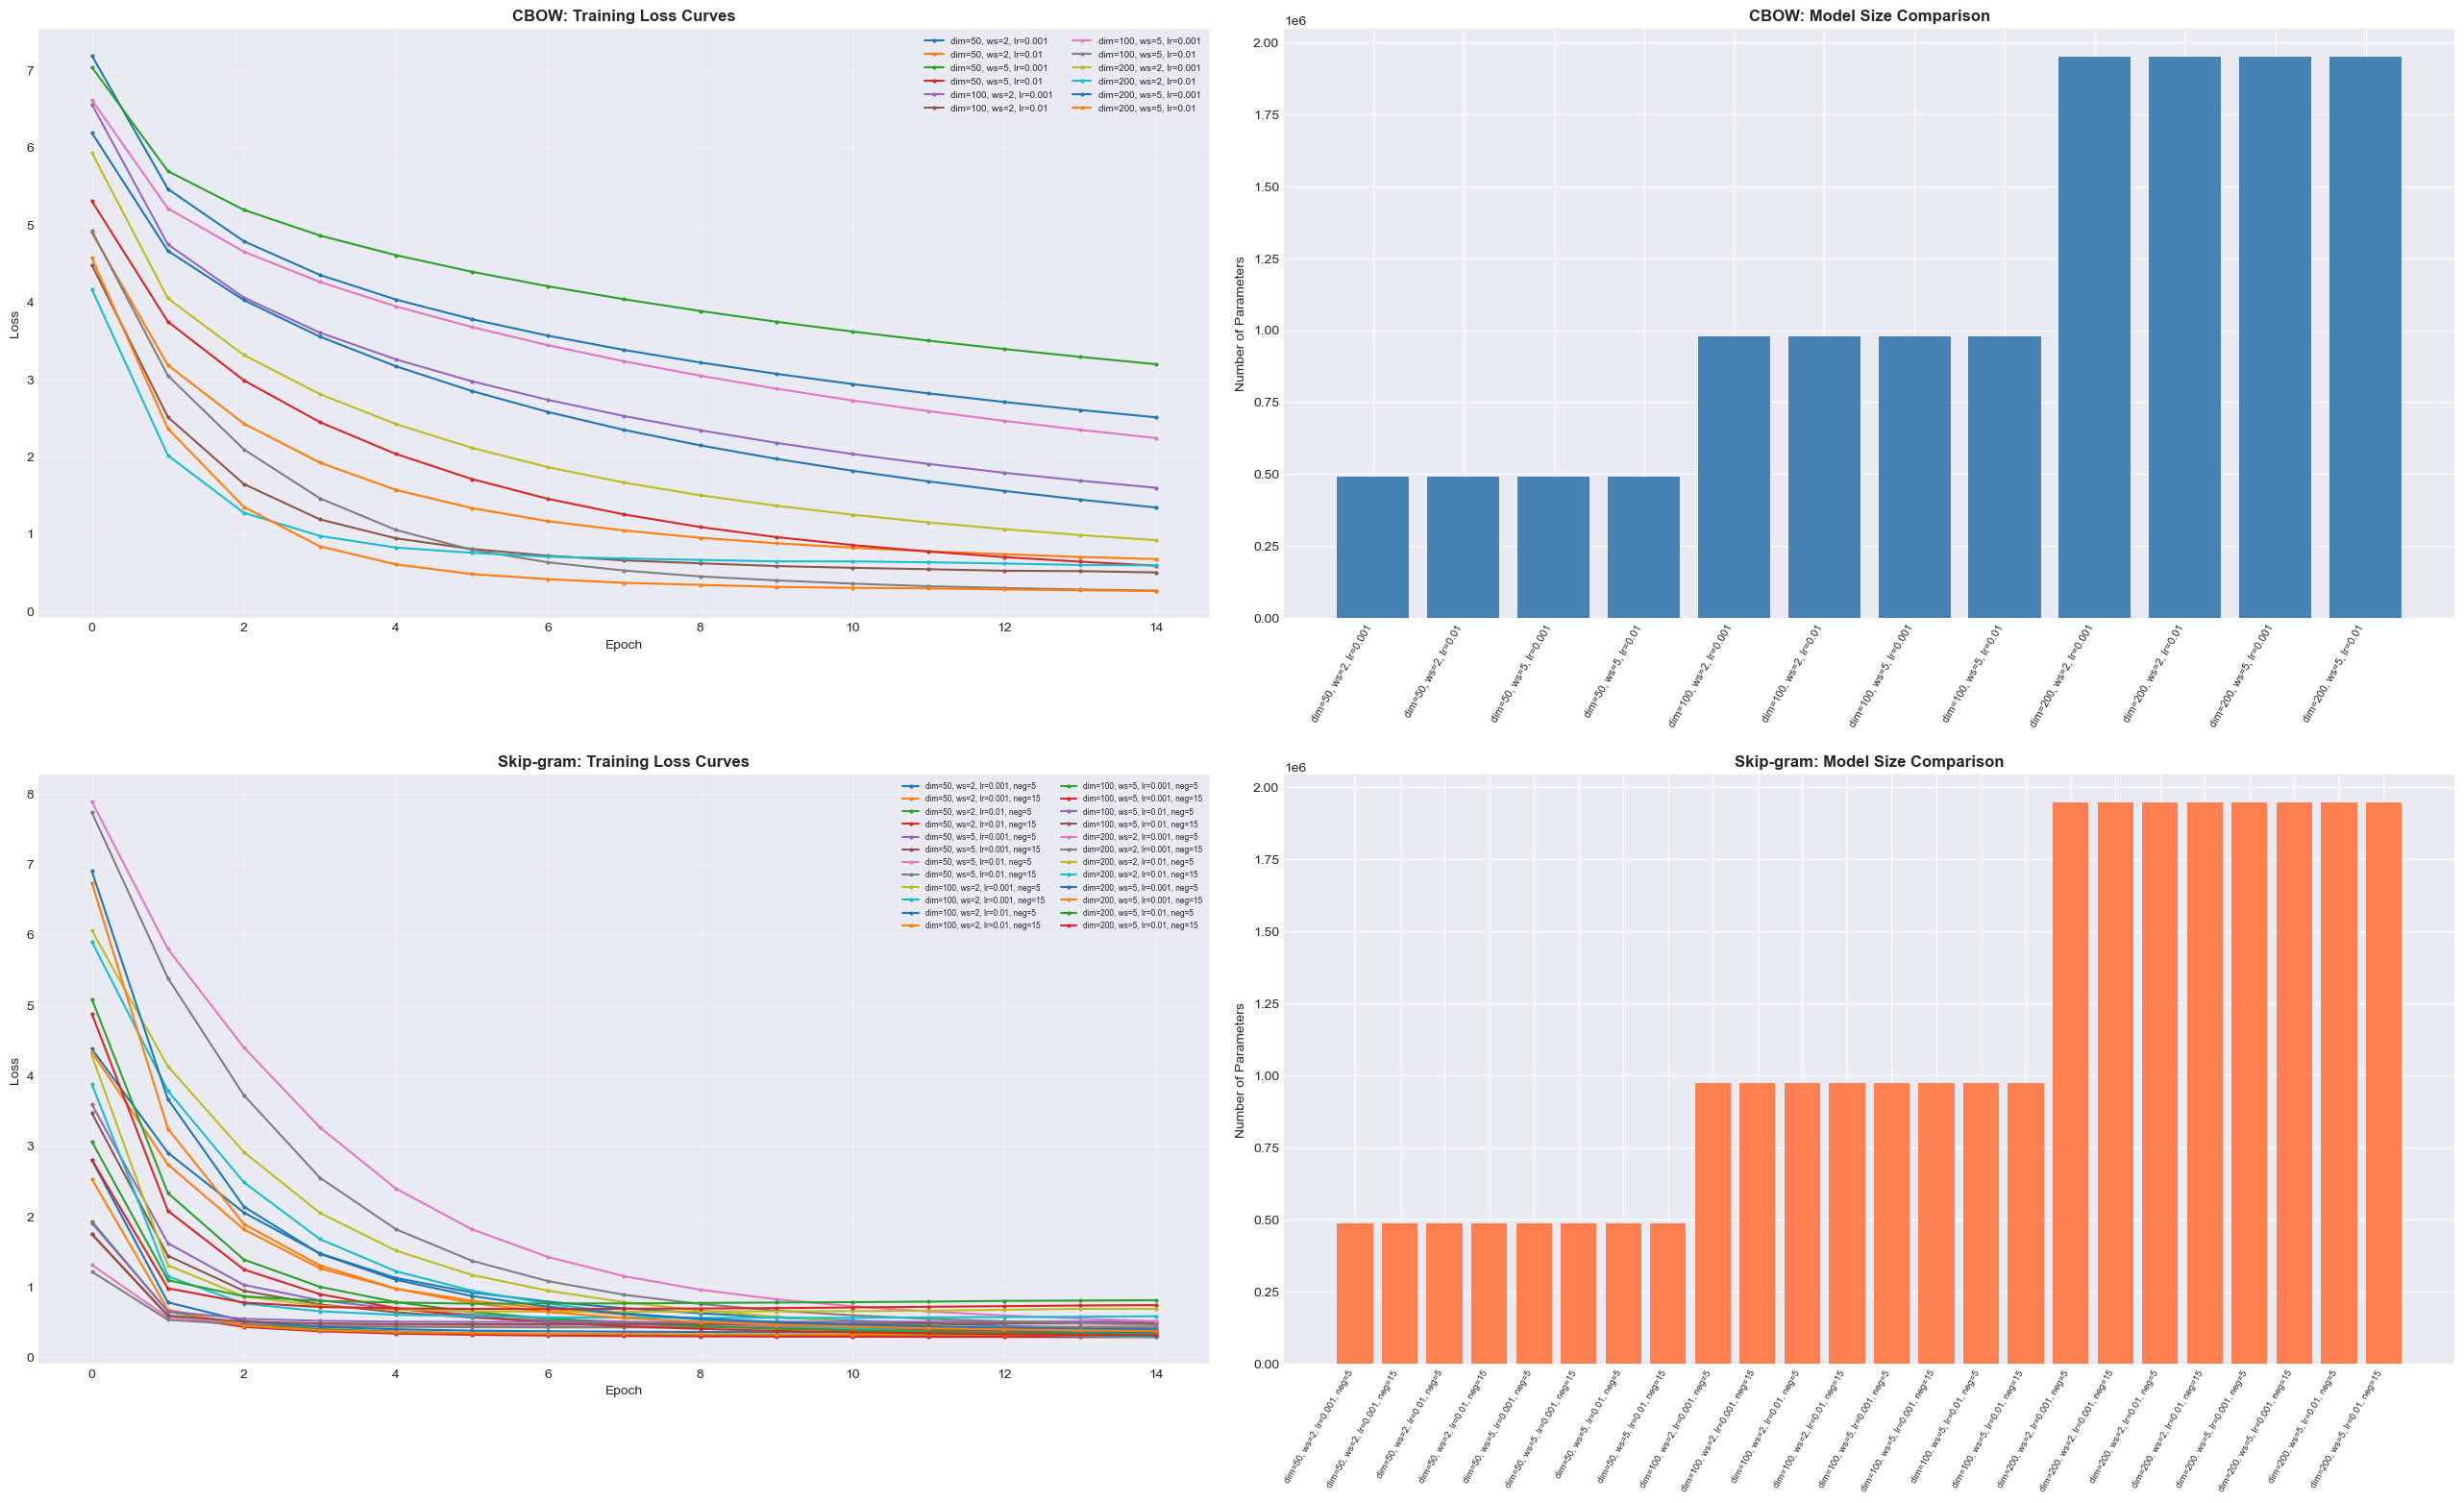

Training curves visualization complete. Plotted 12 CBOW and 24 Skip-gram configs.
Saved: results/training_curves_and_params.png (standard)
Saved: results/training_curves_and_params_ultra_hd.png (ultra-high-res)


In [74]:
"""Task 2: Visualize training loss curves for all models"""

# Plot ALL experiment configurations with a larger canvas for readability
fig, axes = plt.subplots(2, 2, figsize=(26, 16))

# CBOW loss curves
ax = axes[0, 0]
for result in cbow_results:
    label = f"dim={result['embed_dim']}, ws={result['window_size']}, lr={result['learning_rate']}"
    ax.plot(result['losses'], label=label, marker='o', markersize=2, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('CBOW: Training Loss Curves', fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

# CBOW parameter count comparison
ax = axes[0, 1]
cbow_configs = [f"dim={r['embed_dim']}, ws={r['window_size']}, lr={r['learning_rate']}" for r in cbow_results]
cbow_params = [r['num_params'] for r in cbow_results]
ax.bar(range(len(cbow_results)), cbow_params, color='steelblue')
ax.set_ylabel('Number of Parameters')
ax.set_title('CBOW: Model Size Comparison', fontweight='bold')
ax.set_xticks(range(len(cbow_results)))
ax.set_xticklabels(cbow_configs, rotation=60, ha='right', fontsize=8)

# Skip-gram loss curves
ax = axes[1, 0]
for result in skipgram_results:
    label = f"dim={result['embed_dim']}, ws={result['window_size']}, lr={result['learning_rate']}, neg={result['num_neg_samples']}"
    ax.plot(result['losses'], label=label, marker='o', markersize=2, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Skip-gram: Training Loss Curves', fontweight='bold')
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

# Skip-gram parameter count comparison
ax = axes[1, 1]
skipgram_configs = [f"dim={r['embed_dim']}, ws={r['window_size']}, lr={r['learning_rate']}, neg={r['num_neg_samples']}" for r in skipgram_results]
skipgram_params = [r['num_params'] for r in skipgram_results]
ax.bar(range(len(skipgram_results)), skipgram_params, color='coral')
ax.set_ylabel('Number of Parameters')
ax.set_title('Skip-gram: Model Size Comparison', fontweight='bold')
ax.set_xticks(range(len(skipgram_results)))
ax.set_xticklabels(skipgram_configs, rotation=60, ha='right', fontsize=7)

plt.tight_layout(pad=2.0)

# Standard export for quick viewing
plt.savefig('results/training_curves_and_params.png', dpi=200, bbox_inches='tight')

# Ultra-high-resolution export for report/paper usage
plt.savefig('results/training_curves_and_params_ultra_hd.png', dpi=450, bbox_inches='tight')

plt.show()

print(f"Training curves visualization complete. Plotted {len(cbow_results)} CBOW and {len(skipgram_results)} Skip-gram configs.")
print("Saved: results/training_curves_and_params.png (standard)")
print("Saved: results/training_curves_and_params_ultra_hd.png (ultra-high-res)")

In [75]:
"""Task 2: Create model comparison table"""

# CBOW comparison table
cbow_table_data = []
for result in cbow_results:
    cbow_table_data.append({
        'Model Type': result['model_type'],
        'Embedding Dim': result['embed_dim'],
        'Window Size': result['window_size'],
        'Learning Rate': result['learning_rate'],
        'Final Loss': f"{result['final_loss']:.6f}",
        'Parameters': f"{result['num_params']:,}"
    })

cbow_df = pd.DataFrame(cbow_table_data)
print("\n" + "="*100)
print("CBOW MODEL COMPARISON TABLE")
print("="*100)
print(cbow_df.to_string(index=False))

# Skip-gram comparison table
skipgram_table_data = []
for result in skipgram_results:
    skipgram_table_data.append({
        'Model Type': result['model_type'],
        'Embedding Dim': result['embed_dim'],
        'Window Size': result['window_size'],
        'Neg Samples': result['num_neg_samples'],
        'Learning Rate': result['learning_rate'],
        'Final Loss': f"{result['final_loss']:.6f}",
        'Parameters': f"{result['num_params']:,}"
    })

skipgram_df = pd.DataFrame(skipgram_table_data)
print("\n" + "="*100)
print("SKIP-GRAM MODEL COMPARISON TABLE")
print("="*100)
print(skipgram_df.to_string(index=False))


CBOW MODEL COMPARISON TABLE
Model Type  Embedding Dim  Window Size  Learning Rate Final Loss Parameters
      CBOW             50            2          0.001   2.506967    491,163
      CBOW             50            2          0.010   0.673514    491,163
      CBOW             50            5          0.001   3.194575    491,163
      CBOW             50            5          0.010   0.587696    491,163
      CBOW            100            2          0.001   1.595500    977,463
      CBOW            100            2          0.010   0.500288    977,463
      CBOW            100            5          0.001   2.238317    977,463
      CBOW            100            5          0.010   0.264743    977,463
      CBOW            200            2          0.001   0.916840  1,950,063
      CBOW            200            2          0.010   0.591161  1,950,063
      CBOW            200            5          0.001   1.339687  1,950,063
      CBOW            200            5          0.010   0.2

## Task 3: Semantic Analysis (Nearest Neighbors & Analogies)

In [76]:
"""Task 3.1: Nearest Neighbors Analysis using Cosine Similarity"""

def find_nearest_neighbors(embeddings, word_idx, word_to_idx, idx_to_word, k=5):
    """
    Find k nearest neighbors of a word using cosine similarity
    Args:
        embeddings: Word embeddings matrix of shape (vocab_size, embed_dim)
        word_idx: Index of target word
        k: Number of nearest neighbors to return
    Returns:
        List of (word, similarity) tuples
    """
    target_embed = embeddings[word_idx].cpu().numpy()
    all_embeds = embeddings.cpu().numpy()
    
    # Compute cosine similarities
    similarities = []
    for i, embed in enumerate(all_embeds):
        if i != word_idx:
            sim = 1 - cosine(target_embed, embed)
            similarities.append((idx_to_word[i], sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    return similarities[:k]

# Target words for nearest neighbor analysis
target_words = ['research', 'student', 'phd', 'exam', 'course']

print("\n" + "="*100)
print("NEAREST NEIGHBORS ANALYSIS")
print("="*100)

# Select best models (lowest loss) from each type
best_cbow = min(cbow_results, key=lambda x: x['final_loss'])
best_skipgram = min(skipgram_results, key=lambda x: x['final_loss'])

cbow_embeddings = best_cbow['model'].get_embeddings()
skipgram_embeddings = best_skipgram['model'].get_embeddings()

neighbors_results = {}

for word in target_words:
    if word in word_to_idx:
        word_idx = word_to_idx[word]
        
        # CBOW nearest neighbors
        cbow_neighbors = find_nearest_neighbors(cbow_embeddings, word_idx, word_to_idx, idx_to_word, k=5)
        
        # Skip-gram nearest neighbors
        skipgram_neighbors = find_nearest_neighbors(skipgram_embeddings, word_idx, word_to_idx, idx_to_word, k=5)
        
        neighbors_results[word] = {
            'cbow': cbow_neighbors,
            'skipgram': skipgram_neighbors
        }
        
        print(f"\n{'='*80}")
        print(f"Word: '{word.upper()}'")
        print(f"{'='*80}")
        
        print(f"\nCBOW (embed_dim={best_cbow['embed_dim']}, window_size={best_cbow['window_size']}):")
        for neighbor_word, sim in cbow_neighbors:
            print(f"  {neighbor_word:20s} [Similarity: {sim:.4f}]")
        
        print(f"\nSkip-gram (embed_dim={best_skipgram['embed_dim']}, window_size={best_skipgram['window_size']}, neg={best_skipgram['num_neg_samples']}):")
        for neighbor_word, sim in skipgram_neighbors:
            print(f"  {neighbor_word:20s} [Similarity: {sim:.4f}]")
    else:
        print(f"\nWord '{word}' not in vocabulary")

print("\n" + "="*100)


NEAREST NEIGHBORS ANALYSIS

Word: 'RESEARCH'

CBOW (embed_dim=200, window_size=5):
  administration       [Similarity: 0.2956]
  sme                  [Similarity: 0.2734]
  us                   [Similarity: 0.2718]
  archives             [Similarity: 0.2545]
  highlight            [Similarity: 0.2529]

Skip-gram (embed_dim=100, window_size=2, neg=15):
  equivalent           [Similarity: 0.4637]
  mail                 [Similarity: 0.4314]
  newsletter           [Similarity: 0.4282]
  company              [Similarity: 0.4256]
  repository           [Similarity: 0.4185]

Word: 'STUDENT'

CBOW (embed_dim=200, window_size=5):
  applicant            [Similarity: 0.3654]
  coursework           [Similarity: 0.3090]
  strength             [Similarity: 0.2937]
  sister               [Similarity: 0.2886]
  member               [Similarity: 0.2809]

Skip-gram (embed_dim=100, window_size=2, neg=15):
  an                   [Similarity: 0.4895]
  sense                [Similarity: 0.4566]
  her      

In [77]:
"""Task 3.2: Word Analogy Experiments"""

def solve_analogy(embeddings, word_to_idx, idx_to_word, word_a, word_b, word_c, topk=1):
    """
    Solve analogy: word_a : word_b :: word_c : ?
    Using: embedding(?) = embedding(word_b) - embedding(word_a) + embedding(word_c)
    
    Args:
        embeddings: Word embeddings matrix
        word_a, word_b, word_c: Words in the analogy
        topk: Return top-k predictions
    
    Returns:
        List of (word, similarity) tuples for top-k predictions
    """
    if word_a not in word_to_idx or word_b not in word_to_idx or word_c not in word_to_idx:
        return None
    
    idx_a = word_to_idx[word_a]
    idx_b = word_to_idx[word_b]
    idx_c = word_to_idx[word_c]
    
    embed_a = embeddings[idx_a].cpu().numpy()
    embed_b = embeddings[idx_b].cpu().numpy()
    embed_c = embeddings[idx_c].cpu().numpy()
    
    # Compute target embedding
    target_embed = embed_b - embed_a + embed_c
    target_embed = target_embed / (np.linalg.norm(target_embed) + 1e-8)  # Normalize
    
    all_embeds = embeddings.cpu().numpy()
    
    # Compute similarities
    similarities = []
    for i, embed in enumerate(all_embeds):
        # Skip the query words
        if i not in [idx_a, idx_b, idx_c]:
            embed_norm = embed / (np.linalg.norm(embed) + 1e-8)
            sim = np.dot(target_embed, embed_norm)
            similarities.append((idx_to_word[i], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:topk]

# Define analogy experiments
analogies = [
    ('ug', 'btech', 'pg', 'UG : BTech :: PG : ?'),
    ('student', 'learning', 'professor', 'Student : Learning :: Professor : ?'),
    ('course', 'engineering', 'science', 'Course : Engineering :: Science : ?'),
]

print("\n" + "="*100)
print("WORD ANALOGY EXPERIMENTS")
print("="*100)

analogy_results = []

for word_a, word_b, word_c, analogy_str in analogies:
    print(f"\n{'='*80}")
    print(f"Analogy: {analogy_str}")
    print(f"{'='*80}")
    
    # Test with CBOW
    cbow_result = solve_analogy(cbow_embeddings, word_to_idx, idx_to_word, word_a, word_b, word_c, topk=5)
    print(f"\nCBOW Predictions:")
    if cbow_result:
        for pred_word, sim in cbow_result:
            print(f"  {pred_word:20s} [Similarity: {sim:.4f}]")
        analogy_results.append({
            'analogy': analogy_str,
            'model': 'CBOW',
            'top_prediction': cbow_result[0][0],
            'similarity': cbow_result[0][1]
        })
    else:
        print("  Words not found in vocabulary")
    
    # Test with Skip-gram
    skipgram_result = solve_analogy(skipgram_embeddings, word_to_idx, idx_to_word, word_a, word_b, word_c, topk=5)
    print(f"\nSkip-gram Predictions:")
    if skipgram_result:
        for pred_word, sim in skipgram_result:
            print(f"  {pred_word:20s} [Similarity: {sim:.4f}]")
        analogy_results.append({
            'analogy': analogy_str,
            'model': 'Skip-gram',
            'top_prediction': skipgram_result[0][0],
            'similarity': skipgram_result[0][1]
        })
    else:
        print("  Words not found in vocabulary")

print("\n" + "="*100)


WORD ANALOGY EXPERIMENTS

Analogy: UG : BTech :: PG : ?

CBOW Predictions:
  pgs                  [Similarity: 0.3151]
  head                 [Similarity: 0.3019]
  aas                  [Similarity: 0.2869]
  highlights           [Similarity: 0.2816]
  courts               [Similarity: 0.2616]

Skip-gram Predictions:
  sept                 [Similarity: 0.4323]
  reserves             [Similarity: 0.4202]
  particularly         [Similarity: 0.4051]
  connected            [Similarity: 0.4049]
  room                 [Similarity: 0.4016]

Analogy: Student : Learning :: Professor : ?

CBOW Predictions:
  achievements         [Similarity: 0.2828]
  supervisors          [Similarity: 0.2575]
  must                 [Similarity: 0.2400]
  participation        [Similarity: 0.2340]
  enhancement          [Similarity: 0.2338]

Skip-gram Predictions:
  worth                [Similarity: 0.4094]
  overload             [Similarity: 0.3894]
  uba                  [Similarity: 0.3829]
  technique        

## Task 4: Visualization (PCA/t-SNE)

Visualizing 21 words using PCA and t-SNE...


<Figure size 1200x600 with 0 Axes>

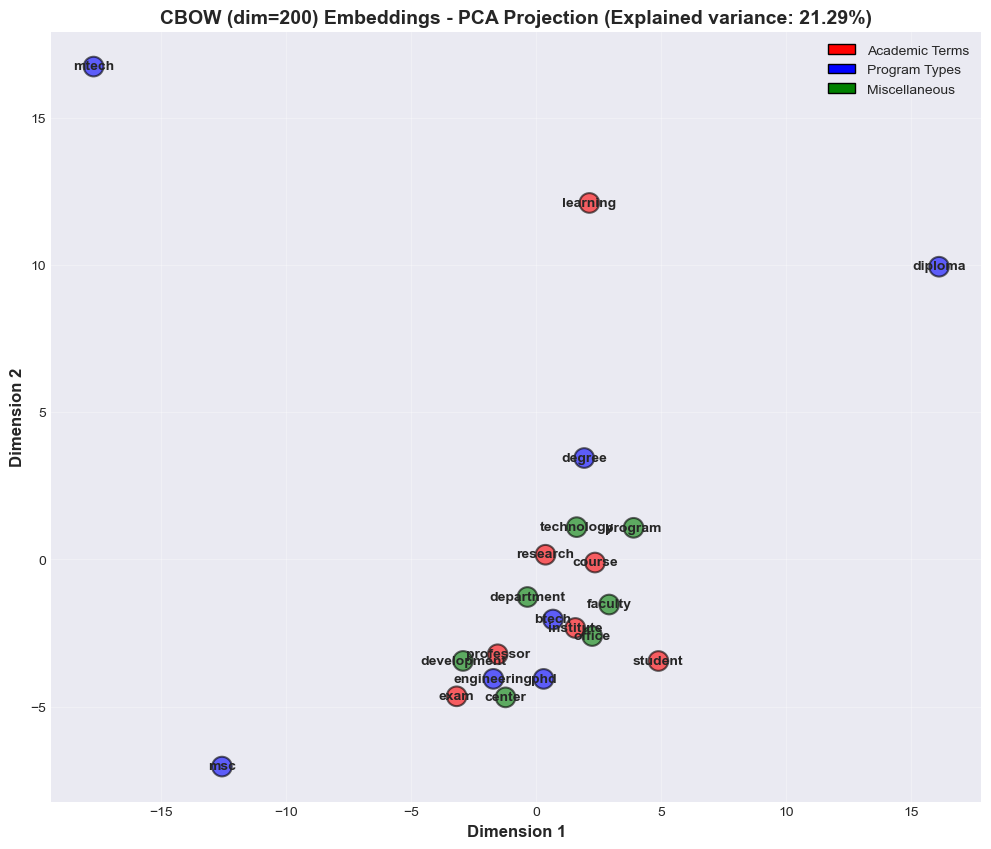

<Figure size 1200x600 with 0 Axes>

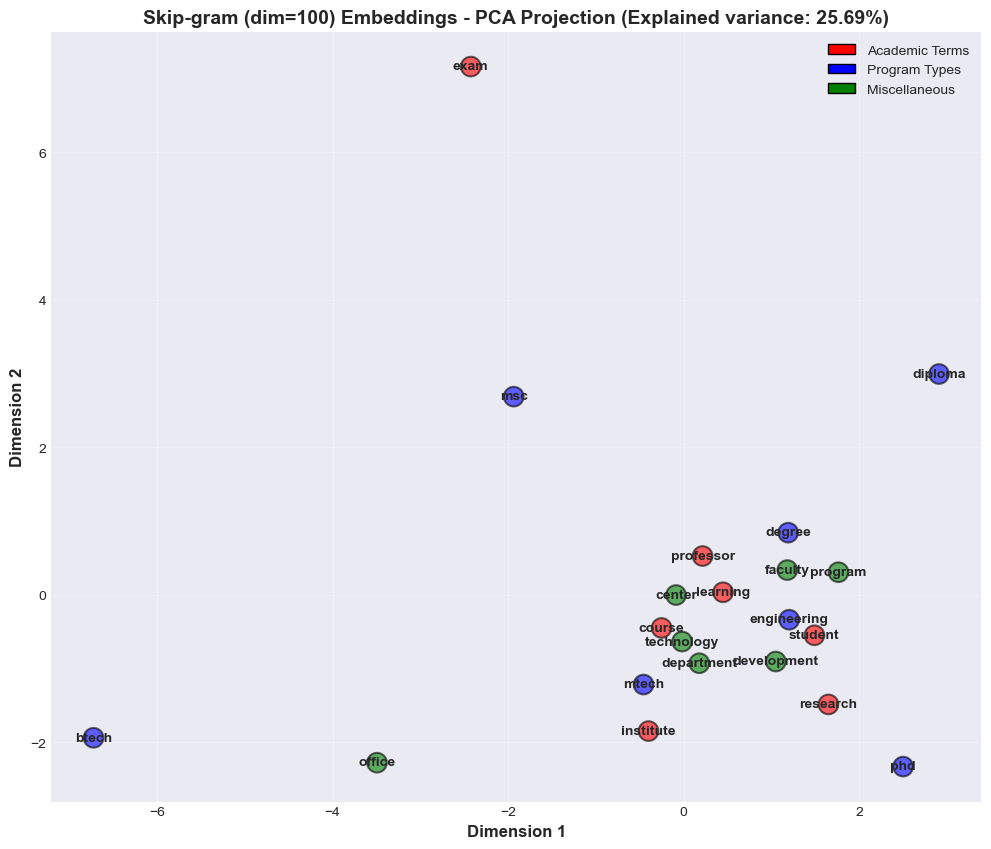

Computing t-SNE projections (this may take a minute)...


<Figure size 1200x600 with 0 Axes>

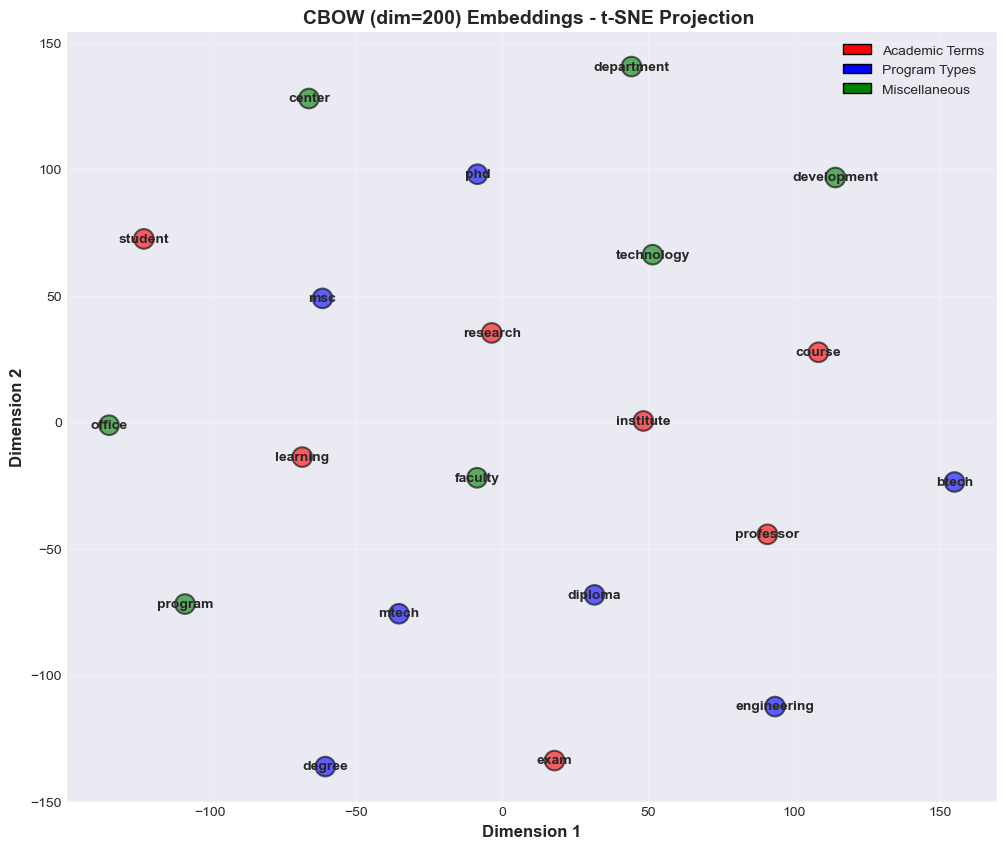

<Figure size 1200x600 with 0 Axes>

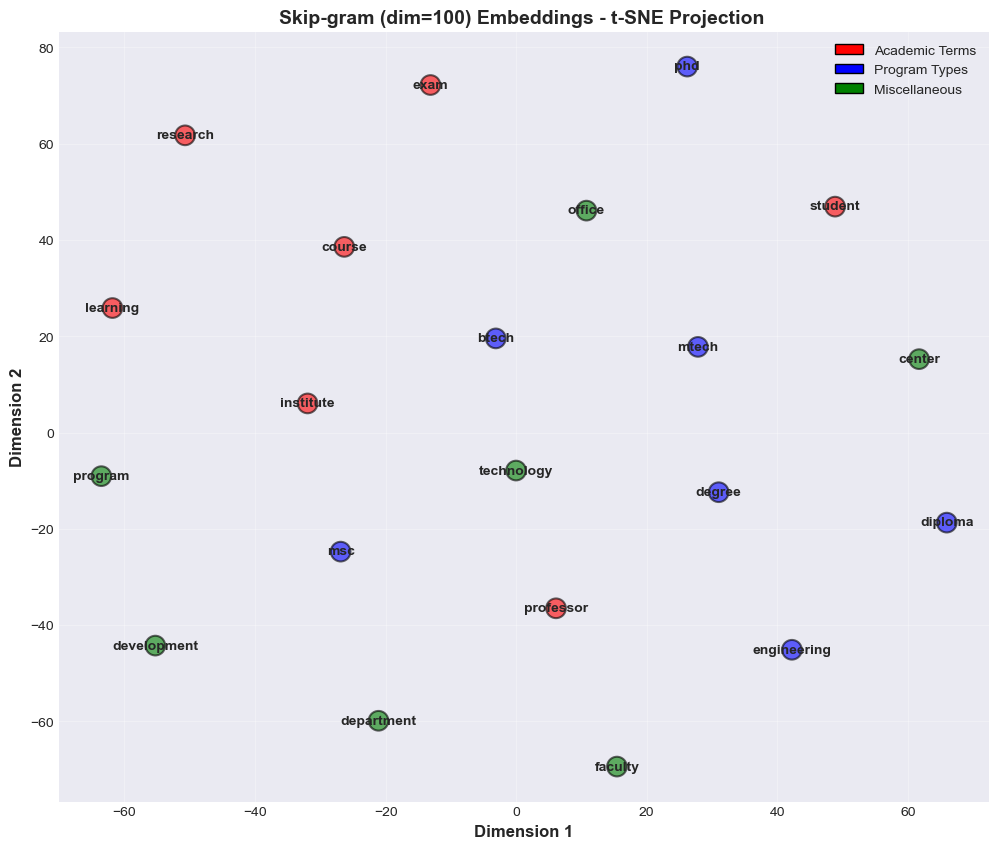


Embedding visualizations complete!


In [78]:
"""Task 4: Visualize embeddings using PCA and t-SNE"""

# Select words for visualization
academic_words = ['research', 'student', 'professor', 'course', 'exam', 'learning', 'institute']
program_words = ['btech', 'mtech', 'msc', 'phd', 'diploma', 'degree', 'engineering']
misc_words = ['technology', 'development', 'program', 'faculty', 'center', 'department', 'office']

visualization_words = academic_words + program_words + misc_words
visualization_words = [w for w in visualization_words if w in word_to_idx]

print(f"Visualizing {len(visualization_words)} words using PCA and t-SNE...")

def visualize_embeddings(embeddings, word_to_idx, idx_to_word, words, model_name, method='pca'):
    """Visualize word embeddings in 2D space"""
    
    # Extract embeddings for selected words
    word_indices = [word_to_idx[w] for w in words if w in word_to_idx]
    selected_embeddings = embeddings[word_indices].cpu().numpy()
    selected_words = [idx_to_word[i] for i in word_indices]
    
    # Apply dimensionality reduction
    if method == 'pca':
        reducer = PCA(n_components=2, random_state=42)
        projection = reducer.fit_transform(selected_embeddings)
        explvar = f"(Explained variance: {reducer.explained_variance_ratio_.sum():.2%})"
    else:  # t-SNE
        reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(selected_words)-1))
        projection = reducer.fit_transform(selected_embeddings)
        explvar = ""
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Define colors for categories
    colors = []
    for word in selected_words:
        if word in academic_words:
            colors.append('red')
        elif word in program_words:
            colors.append('blue')
        else:
            colors.append('green')
    
    # Scatter plot
    scatter = ax.scatter(projection[:, 0], projection[:, 1], c=colors, s=200, alpha=0.6, edgecolors='black', linewidth=1.5)
    
    # Add word labels
    for i, word in enumerate(selected_words):
        ax.annotate(word, (projection[i, 0], projection[i, 1]), 
                   fontsize=10, fontweight='bold', ha='center', va='center')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', edgecolor='black', label='Academic Terms'),
        Patch(facecolor='blue', edgecolor='black', label='Program Types'),
        Patch(facecolor='green', edgecolor='black', label='Miscellaneous')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    ax.set_xlabel(f'Dimension 1', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Dimension 2', fontsize=12, fontweight='bold')
    method_display = 'PCA' if method == 'pca' else 't-SNE'
    ax.set_title(f'{model_name} Embeddings - {method_display} Projection {explvar}', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    return fig

# PCA visualization
plt.figure()
fig_cbow_pca = visualize_embeddings(cbow_embeddings, word_to_idx, idx_to_word, 
                                    visualization_words, f'CBOW (dim={best_cbow["embed_dim"]})', method='pca')
plt.savefig('results/cbow_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
fig_skipgram_pca = visualize_embeddings(skipgram_embeddings, word_to_idx, idx_to_word, 
                                       visualization_words, f'Skip-gram (dim={best_skipgram["embed_dim"]})', method='pca')
plt.savefig('results/skipgram_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# t-SNE visualization
print("Computing t-SNE projections (this may take a minute)...")
plt.figure()
fig_cbow_tsne = visualize_embeddings(cbow_embeddings, word_to_idx, idx_to_word, 
                                    visualization_words, f'CBOW (dim={best_cbow["embed_dim"]})', method='tsne')
plt.savefig('results/cbow_tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
fig_skipgram_tsne = visualize_embeddings(skipgram_embeddings, word_to_idx, idx_to_word, 
                                        visualization_words, f'Skip-gram (dim={best_skipgram["embed_dim"]})', method='tsne')
plt.savefig('results/skipgram_tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEmbedding visualizations complete!")

---
# PROBLEM 2: CHARACTER-LEVEL NAME GENERATION USING RNNs
---

## Task 0: Prepare Dataset

In [94]:
"""Task 0: Load Indian Names Dataset"""

# Check if user has provided TrainingNames.txt
if os.path.exists('data/TrainingNames.txt'):
    with open('data/TrainingNames.txt', 'r', encoding='utf-8') as f:
        names = [line.strip() for line in f.readlines() if line.strip()]
    print(f"Loaded {len(names)} Indian names from data/TrainingNames.txt")
else:
    print("\nTrainingNames.txt not found!")
    print("Please generate 1000 Indian names using an LLM and save them to data/TrainingNames.txt")
    print("One name per line, in English text only.")
    names = []  # Empty for now

print(f"\nDataset size: {len(names)} names")
if names:
    print(f"Sample names: {names[:10]}")

Loaded 1000 Indian names from data/TrainingNames.txt

Dataset size: 1000 names
Sample names: ['Aadesh', 'Aadika', 'Aadish', 'Aadita', 'Aadra', 'Aadul', 'Aarali', 'Aaras', 'Aarav', 'Aaren']


In [95]:
"""Task 0.2: Character level dataset preparation for RNN models"""

if len(names) > 0:
    # Build character vocabulary with explicit special tokens
    all_chars = set()
    for name in names:
        all_chars.update(name.lower())

    special_tokens = ['<pad>', '<bos>', '<eos>']
    char_list = special_tokens + sorted(list(all_chars))
    char_to_idx = {char: idx for idx, char in enumerate(char_list)}
    idx_to_char = {idx: char for char, idx in char_to_idx.items()}

    PAD_IDX = char_to_idx['<pad>']
    BOS_IDX = char_to_idx['<bos>']
    EOS_IDX = char_to_idx['<eos>']

    print(f"\nCharacter vocabulary size: {len(char_list)}")
    print(f"Special tokens: {special_tokens}")
    print(f"Characters: {char_list[3:]}")

    class NameDataset(torch.utils.data.Dataset):
        """Dataset for autoregressive next-character prediction"""

        def __init__(self, names, char_to_idx):
            self.names = names
            self.char_to_idx = char_to_idx
            self.bos = char_to_idx['<bos>']
            self.eos = char_to_idx['<eos>']

        def __len__(self):
            return len(self.names)

        def __getitem__(self, idx):
            name = self.names[idx].lower()
            core = [self.char_to_idx[c] for c in name if c in self.char_to_idx]

            # Input is BOS + chars, target is chars + EOS
            input_seq = [self.bos] + core
            target_seq = core + [self.eos]

            return (
                torch.tensor(input_seq, dtype=torch.long),
                torch.tensor(target_seq, dtype=torch.long)
            )

    def collate_batch(batch):
        """Pad variable-length input/target sequences in a batch"""
        inputs, targets = zip(*batch)
        input_padded = torch.nn.utils.rnn.pad_sequence(
            inputs,
            batch_first=True,
            padding_value=PAD_IDX
        )
        target_padded = torch.nn.utils.rnn.pad_sequence(
            targets,
            batch_first=True,
            padding_value=PAD_IDX
        )
        lengths = torch.tensor([len(x) for x in inputs], dtype=torch.long)
        return input_padded, target_padded, lengths

    # Create dataset
    name_dataset = NameDataset(names, char_to_idx)
    print(f"\nDataset ready: {len(name_dataset)} training examples")
else:
    print("\nSkipping RNN models - waiting for TrainingNames.txt")
    char_to_idx = {}
    idx_to_char = {}


Character vocabulary size: 24
Special tokens: ['<pad>', '<bos>', '<eos>']
Characters: ['a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y']

Dataset ready: 1000 training examples


## Task 1: RNN Model Implementations

In [97]:
"""Task 1.1: Vanilla RNN Implementation from Scratch"""

class ManualRNNCell(nn.Module):
    """Single RNN cell implemented from basic linear layers."""

    def __init__(self, input_size, hidden_size):
        super(ManualRNNCell, self).__init__()
        self.in_linear = nn.Linear(input_size, hidden_size, bias=True)
        self.h_linear = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        return torch.tanh(self.in_linear(x_t) + self.h_linear(h_prev))


class ManualLSTMCell(nn.Module):
    """Single LSTM cell implemented from gate equations."""

    def __init__(self, input_size, hidden_size):
        super(ManualLSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size, bias=True)

    def forward(self, x_t, state):
        h_prev, c_prev = state
        combined = torch.cat([x_t, h_prev], dim=1)
        gate_values = self.gates(combined)
        i_gate, f_gate, g_gate, o_gate = torch.chunk(gate_values, 4, dim=1)

        i_gate = torch.sigmoid(i_gate)
        f_gate = torch.sigmoid(f_gate)
        g_gate = torch.tanh(g_gate)
        o_gate = torch.sigmoid(o_gate)

        c_t = f_gate * c_prev + i_gate * g_gate
        h_t = o_gate * torch.tanh(c_t)
        return h_t, c_t


class VanillaRNN(nn.Module):
    """Vanilla Recurrent Neural Network built from scratch"""
    
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.0):
        """
        Args:
            input_size: Size of input (vocabulary or character set)
            hidden_size: Size of hidden state
            output_size: Size of output (for classification or generation)
            num_layers: Number of RNN layers
            dropout: Dropout rate
        """
        super(VanillaRNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        
        # Character embedding layer
        self.embed = nn.Embedding(num_embeddings=input_size, embedding_dim=hidden_size)
        
        # Stack of custom RNN cells
        self.rnn_cells = nn.ModuleList([
            ManualRNNCell(input_size=hidden_size, hidden_size=hidden_size)
            for _ in range(num_layers)
        ])
        
        # Output layer
        self.decoder = nn.Linear(in_features=hidden_size, out_features=output_size)
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, x, hidden_states=None):
        """
        Forward pass
        Args:
            x: Tensor of shape (batch_size, seq_len) with character indices
            hidden_states: Initial hidden states for each layer
        Returns:
            logits: Tensor of shape (batch_size, seq_len, output_size)
            hidden_states: List of hidden states for each layer
        """
        batch_size, seq_len = x.shape
        
        # Initialize hidden states
        if hidden_states is None:
            hidden_states = [torch.zeros(batch_size, self.hidden_size, device=x.device) 
                            for _ in range(self.num_layers)]
        else:
            hidden_states = [h for h in hidden_states]
        
        # Embed input
        x_embed = self.embed(x)  # (batch, seq_len, hidden_size)

        logits = []
        
        # Process sequence
        for t in range(seq_len):
            x_t = x_embed[:, t, :]  # (batch, hidden_size)
            
            # Pass through RNN layers
            for layer_idx, rnn_cell in enumerate(self.rnn_cells):
                hidden_states[layer_idx] = rnn_cell(x_t, hidden_states[layer_idx])
                x_t = self.dropout(hidden_states[layer_idx])
            
            # Output layer
            logits_t = self.decoder(hidden_states[-1])  # (batch, output_size)
            logits.append(logits_t)
        
        # Stack logits
        logits = torch.stack(logits, dim=1)  # (batch, seq_len, output_size)
        
        return logits, hidden_states
    
    def count_parameters(self):
        """Count trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Vanilla RNN class defined.")

Vanilla RNN class defined.


In [98]:
"""Task 1.2: Bidirectional LSTM Implementation"""

class BiLSTM(nn.Module):
    """Bidirectional LSTM for character-level name generation"""
    
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.0):
        """
        Args:
            input_size: Size of input vocabulary
            hidden_size: Size of hidden state in each LSTM cell
            output_size: Size of output
            num_layers: Number of stacked bidirectional layers
            dropout: Dropout rate
        """
        super(BiLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        
        # Character embedding
        self.embed = nn.Embedding(num_embeddings=input_size, embedding_dim=hidden_size)
        
        # Manual bidirectional LSTM cells per layer
        self.fwd_cells = nn.ModuleList([
            ManualLSTMCell(input_size=hidden_size if i == 0 else 2 * hidden_size, hidden_size=hidden_size)
            for i in range(num_layers)
        ])
        self.bwd_cells = nn.ModuleList([
            ManualLSTMCell(input_size=hidden_size if i == 0 else 2 * hidden_size, hidden_size=hidden_size)
            for i in range(num_layers)
        ])
        
        # Output layer (input is 2*hidden_size due to bidirectional)
        self.decoder = nn.Linear(in_features=2 * hidden_size, out_features=output_size)
        self.dropout = nn.Dropout(p=dropout)
    
    def _init_state(self, batch_size, device):
        zero_state = torch.zeros(batch_size, self.hidden_size, device=device)
        return [
            (zero_state.clone(), zero_state.clone())
            for _ in range(self.num_layers)
        ]
    
    def forward(self, x, hidden_states=None):
        """
        Forward pass
        Args:
            x: Tensor of shape (batch_size, seq_len) with character indices
            hidden_states: Tuple (fwd_states, bwd_states), each a list of (h, c) per layer
        Returns:
            logits: Tensor of shape (batch_size, seq_len, output_size)
            hidden_states: Tuple (fwd_states, bwd_states)
        """
        batch_size, seq_len = x.shape
        
        # Embed input
        layer_input = self.dropout(self.embed(x))  # (batch, seq_len, hidden_size)
        
        if hidden_states is None:
            fwd_states = self._init_state(batch_size, x.device)
            bwd_states = self._init_state(batch_size, x.device)
        else:
            fwd_states, bwd_states = hidden_states
            fwd_states = [(h, c) for (h, c) in fwd_states]
            bwd_states = [(h, c) for (h, c) in bwd_states]

        # Process stacked bidirectional layers
        for layer_idx in range(self.num_layers):
            fwd_outputs = []
            bwd_outputs_rev = []

            # Forward direction
            h_fwd, c_fwd = fwd_states[layer_idx]
            for t in range(seq_len):
                h_fwd, c_fwd = self.fwd_cells[layer_idx](layer_input[:, t, :], (h_fwd, c_fwd))
                fwd_outputs.append(h_fwd.unsqueeze(1))
            fwd_states[layer_idx] = (h_fwd, c_fwd)

            # Backward direction
            h_bwd, c_bwd = bwd_states[layer_idx]
            for t in range(seq_len - 1, -1, -1):
                h_bwd, c_bwd = self.bwd_cells[layer_idx](layer_input[:, t, :], (h_bwd, c_bwd))
                bwd_outputs_rev.append(h_bwd.unsqueeze(1))
            bwd_states[layer_idx] = (h_bwd, c_bwd)

            fwd_seq = torch.cat(fwd_outputs, dim=1)
            bwd_seq = torch.cat(list(reversed(bwd_outputs_rev)), dim=1)
            layer_output = torch.cat([fwd_seq, bwd_seq], dim=2)  # (batch, seq_len, 2*hidden)
            layer_input = self.dropout(layer_output)

        # Output layer
        logits = self.decoder(layer_input)  # (batch, seq_len, output_size)
        return logits, (fwd_states, bwd_states)
    
    def count_parameters(self):
        """Count trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("BiLSTM class defined.")

BiLSTM class defined.


In [99]:
"""Task 1.3: RNN with Attention Mechanism"""

class RNNWithAttention(nn.Module):
    """RNN with Scaled Dot-Product Attention mechanism"""
    
    def __init__(self, input_size, hidden_size, output_size, attention_dim=None, num_layers=1, dropout=0.0):
        """
        Args:
            input_size: Size of input vocabulary
            hidden_size: Size of hidden state
            output_size: Size of output
            attention_dim: Dimension of attention mechanism (default: hidden_size)
            num_layers: Number of recurrent layers
            dropout: Dropout rate
        """
        super(RNNWithAttention, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.attention_dim = attention_dim or hidden_size
        self.num_layers = num_layers
        
        # Character embedding
        self.embed = nn.Embedding(num_embeddings=input_size, embedding_dim=hidden_size)
        
        # Manual recurrent stack (LSTM-style cells)
        self.rnn_cells = nn.ModuleList([
            ManualLSTMCell(input_size=hidden_size if i == 0 else hidden_size, hidden_size=hidden_size)
            for i in range(num_layers)
        ])
        
        # Attention mechanism
        self.attention_query = nn.Linear(hidden_size, self.attention_dim)
        self.attention_key = nn.Linear(hidden_size, self.attention_dim)
        self.attention_value = nn.Linear(hidden_size, self.attention_dim)
        
        # Output layer (combines context vector with current hidden state)
        self.decoder = nn.Linear(hidden_size + self.attention_dim, output_size)
        self.dropout = nn.Dropout(p=dropout)
        
        # Scale factor for attention
        self.scale = np.sqrt(self.attention_dim)
    
    def compute_attention(self, query, keys, values):
        """
        Compute scaled dot-product attention
        Args:
            query: Shape (batch_size, attention_dim)
            keys: Shape (batch_size, seq_len, attention_dim)
            values: Shape (batch_size, seq_len, attention_dim)
        Returns:
            context: Shape (batch_size, attention_dim)
            attention_weights: Shape (batch_size, seq_len)
        """
        # Compute attention scores
        scores = torch.bmm(keys, query.unsqueeze(2)).squeeze(2) / self.scale  # (batch, seq_len)
        
        # Softmax to get attention weights
        attention_weights = torch.softmax(scores, dim=1)  # (batch, seq_len)
        
        # Apply attention to values
        context = torch.bmm(attention_weights.unsqueeze(1), values).squeeze(1)  # (batch, attention_dim)
        
        return context, attention_weights
    
    def forward(self, x, all_hidden_states=None):
        """
        Forward pass with attention
        Args:
            x: Tensor of shape (batch_size, seq_len) with character indices
            all_hidden_states: Optional warm-start history from previous call
        Returns:
            logits: Tensor of shape (batch_size, seq_len, output_size)
            all_hidden_states: All hidden states for attention computation
        """
        batch_size, seq_len = x.shape
        
        # Initialize hidden and cell states
        hidden_states = [torch.zeros(batch_size, self.hidden_size, device=x.device) 
                         for _ in range(self.num_layers)]
        cell_states = [torch.zeros(batch_size, self.hidden_size, device=x.device) 
                       for _ in range(self.num_layers)]
        
        # Embed input
        x_embed = self.embed(x)  # (batch, seq_len, hidden_size)
        
        logits = []
        all_states_history = []

        # If previous hidden-state history is provided, prepend it for attention context
        if all_hidden_states is not None and len(all_hidden_states) > 0:
            all_states_history.extend(all_hidden_states)
        
        # Process sequence
        for t in range(seq_len):
            x_t = x_embed[:, t, :]  # (batch, hidden_size)
            
            # Recurrent stack forward pass
            for layer_idx, lstm_cell in enumerate(self.rnn_cells):
                hidden_states[layer_idx], cell_states[layer_idx] = lstm_cell(
                    x_t, (hidden_states[layer_idx], cell_states[layer_idx])
                )
                x_t = self.dropout(hidden_states[layer_idx])
            
            # Store current hidden state
            all_states_history.append(hidden_states[-1].unsqueeze(1))  # (batch, 1, hidden_size)
            
            # Compute attention (over all previous states)
            if len(all_states_history) > 1:
                all_prev_states = torch.cat(all_states_history[:-1], dim=1)  # (batch, t, hidden_size)
                
                # Project for attention
                query = self.attention_query(hidden_states[-1])  # (batch, attention_dim)
                keys = self.attention_key(all_prev_states)  # (batch, t, attention_dim)
                values = self.attention_value(all_prev_states)  # (batch, t, attention_dim)
                
                # Compute attention
                context, _ = self.compute_attention(query, keys, values)  # (batch, attention_dim)
            else:
                context = torch.zeros(batch_size, self.attention_dim, device=x.device)
            
            # Combine context with final hidden state
            combined = torch.cat([hidden_states[-1], context], dim=1)  # (batch, hidden_size + attention_dim)
            logits_t = self.decoder(combined)  # (batch, output_size)
            logits.append(logits_t)
        
        # Stack logits
        logits = torch.stack(logits, dim=1)  # (batch, seq_len, output_size)
        
        return logits, all_states_history
    
    def count_parameters(self):
        """Count trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("RNN with Attention class defined.")

RNN with Attention class defined.


In [100]:
"""Task 2: Training RNN Models"""

if len(names) > 100:
    print("\nTraining RNN models for character-level name generation...")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Quick mode for faster experimentation
    QUICK_MODE_RNN = False
    if QUICK_MODE_RNN:
        HIDDEN_SIZE = 96
        NUM_LAYERS = 1
        LEARNING_RATE = 0.001
        EPOCHS = 10
        BATCH_SIZE = 32
        MAX_BATCHES_PER_EPOCH = 80
    else:
        HIDDEN_SIZE = 128
        NUM_LAYERS = 1
        LEARNING_RATE = 0.001
        EPOCHS = 30
        BATCH_SIZE = 32
        MAX_BATCHES_PER_EPOCH = None

    # Create dataloader
    name_dataloader = DataLoader(name_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)

    # Initialize models
    vocab_size = len(char_to_idx)
    output_size = len(char_to_idx)  # Output is next-character prediction

    vanilla_rnn = VanillaRNN(vocab_size, HIDDEN_SIZE, output_size, num_layers=NUM_LAYERS, dropout=0.3).to(device)
    bilstm = BiLSTM(vocab_size, HIDDEN_SIZE, output_size, num_layers=NUM_LAYERS, dropout=0.3).to(device)
    rnn_attention = RNNWithAttention(vocab_size, HIDDEN_SIZE, output_size, attention_dim=64, num_layers=NUM_LAYERS, dropout=0.3).to(device)

    rnn_models = {
        'Vanilla RNN': vanilla_rnn,
        'BiLSTM': bilstm,
        'RNN with Attention': rnn_attention
    }

    # Print model architectures
    print("\n" + "="*80)
    print("MODEL ARCHITECTURES")
    print("="*80)

    for model_name, model in rnn_models.items():
        num_params = model.count_parameters()
        print(f"\n{model_name}:")
        print(f"  Trainable Parameters: {num_params:,}")
        print(f"  Architecture:")
        for name, module in model.named_parameters():
            print(f"    {name}: {module.shape}")

    # Training function
    def train_model(model, model_name, device, dataloader, epochs, learning_rate, max_batches_per_epoch=None):
        """Train a single model"""
        criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        train_losses = []

        print(f"\nTraining {model_name}...")
        for epoch in range(epochs):
            total_loss = 0.0
            num_batches = 0

            for batch_inputs, batch_targets, _ in dataloader:
                batch_inputs = batch_inputs.to(device)
                batch_targets = batch_targets.to(device)

                # Forward pass
                logits, _ = model(batch_inputs)

                # Reshape for loss computation
                bsz, seq_len, vocab_size = logits.shape
                logits_reshaped = logits.view(bsz * seq_len, vocab_size)
                targets_reshaped = batch_targets.view(bsz * seq_len)

                # Compute loss
                loss = criterion(logits_reshaped, targets_reshaped)

                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
                optimizer.step()

                total_loss += loss.item()
                num_batches += 1
                if max_batches_per_epoch is not None and num_batches >= max_batches_per_epoch:
                    break

            avg_loss = total_loss / max(1, num_batches)
            train_losses.append(avg_loss)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

        return model, train_losses

    # Train all models
    trained_models = {}
    training_losses = {}

    for model_name, model in rnn_models.items():
        trained_model, losses = train_model(
            model, model_name, device, name_dataloader, EPOCHS, LEARNING_RATE,
            max_batches_per_epoch=MAX_BATCHES_PER_EPOCH
        )
        trained_models[model_name] = trained_model
        training_losses[model_name] = losses

    print("\nAll models trained successfully!")
else:
    print("\nInsufficient training data for RNN models.")
    print(f"Current size: {len(names)}, Required: > 100")
    trained_models = {}
    training_losses = {}


Training RNN models for character-level name generation...

MODEL ARCHITECTURES

Vanilla RNN:
  Trainable Parameters: 39,064
  Architecture:
    embed.weight: torch.Size([24, 128])
    rnn_cells.0.in_linear.weight: torch.Size([128, 128])
    rnn_cells.0.in_linear.bias: torch.Size([128])
    rnn_cells.0.h_linear.weight: torch.Size([128, 128])
    decoder.weight: torch.Size([24, 128])
    decoder.bias: torch.Size([24])

BiLSTM:
  Trainable Parameters: 272,408
  Architecture:
    embed.weight: torch.Size([24, 128])
    fwd_cells.0.gates.weight: torch.Size([512, 256])
    fwd_cells.0.gates.bias: torch.Size([512])
    bwd_cells.0.gates.weight: torch.Size([512, 256])
    bwd_cells.0.gates.bias: torch.Size([512])
    decoder.weight: torch.Size([24, 256])
    decoder.bias: torch.Size([24])

RNN with Attention:
  Trainable Parameters: 164,056
  Architecture:
    embed.weight: torch.Size([24, 128])
    rnn_cells.0.gates.weight: torch.Size([512, 256])
    rnn_cells.0.gates.bias: torch.Size([512]

In [101]:
"""Task 3: Generate Names and Evaluate Models"""

if len(trained_models) > 0:
    print("\n" + "="*80)
    print("NAME GENERATION AND EVALUATION")
    print("="*80)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    pad_idx = char_to_idx.get('<pad>', None)
    bos_idx = char_to_idx.get('<bos>', None)
    eos_idx = char_to_idx.get('<eos>', None)

    def is_valid_generated_name(name):
        """Reject obviously degenerate outputs and keep human-like name shapes."""
        name_l = name.lower()
        if len(name_l) < 3 or len(name_l) > 15:
            return False
        if len(set(name_l)) < 2:
            return False
        max_char_ratio = max(name_l.count(c) for c in set(name_l)) / len(name_l)
        if max_char_ratio > 0.55:
            return False
        vowels = set('aeiou')
        if not any(c in vowels for c in name_l):
            return False
        return True

    def sample_next_char(logit_vec, temperature=1.05, top_k=10, forbidden_indices=None, recent_indices=None):
        """Temperature + top-k sampling with repetition penalty."""
        logits = logit_vec.clone()

        if recent_indices is not None:
            for idx in recent_indices[-3:]:
                logits[idx] = logits[idx] / 1.4

        if forbidden_indices:
            for idx in forbidden_indices:
                if idx is not None and 0 <= idx < logits.shape[0]:
                    logits[idx] = -1e9

        scaled = logits / max(1e-6, temperature)
        probs = torch.softmax(scaled, dim=0)

        k = min(top_k, probs.shape[0])
        top_probs, top_idx = torch.topk(probs, k)
        top_probs = top_probs / top_probs.sum()
        chosen = top_idx[torch.multinomial(top_probs, 1).item()].item()
        return chosen

    def generate_names(model, num_names, max_length=15):
        """Generate names autoregressively from BOS to EOS."""
        model.eval()
        generated_names = []
        attempts = 0
        max_attempts = max(300, num_names * 20)

        # Allowed output chars exclude special tokens
        forbidden = []
        if pad_idx is not None:
            forbidden.append(pad_idx)
        if bos_idx is not None:
            forbidden.append(bos_idx)

        with torch.no_grad():
            while len(generated_names) < num_names and attempts < max_attempts:
                attempts += 1
                token_ids = [bos_idx] if bos_idx is not None else []

                for _ in range(max_length):
                    if len(token_ids) == 0:
                        break

                    x = torch.tensor([token_ids], dtype=torch.long, device=device)
                    logits, _ = model(x)
                    next_logits = logits[0, -1, :]
                    next_idx = sample_next_char(
                        next_logits,
                        temperature=1.05,
                        top_k=10,
                        forbidden_indices=forbidden,
                        recent_indices=token_ids
                    )

                    if eos_idx is not None and next_idx == eos_idx:
                        break

                    token_ids.append(next_idx)

                # Decode: skip BOS and special tokens
                decoded_chars = []
                for idx in token_ids:
                    ch = idx_to_char.get(idx, '')
                    if ch in ('<pad>', '<bos>', '<eos>'):
                        continue
                    decoded_chars.append(ch)

                generated_name = ''.join(decoded_chars).strip().title()
                if is_valid_generated_name(generated_name):
                    generated_names.append(generated_name)

        # Remove duplicates for reporting
        unique_names = []
        seen = set()
        for n in generated_names:
            key = n.lower()
            if key not in seen:
                seen.add(key)
                unique_names.append(n)
        return unique_names

    def evaluate_generation(generated_names, training_names):
        """Evaluate generated names using novelty and diversity metrics"""
        training_set = set(n.lower() for n in training_names)

        novel_names = [name for name in generated_names if name.lower() not in training_set]
        novelty_rate = len(novel_names) / len(generated_names) if generated_names else 0

        unique_names = set(generated_names)
        diversity = len(unique_names) / len(generated_names) if generated_names else 0

        return {
            'novelty_rate': novelty_rate,
            'diversity': diversity,
            'num_generated': len(generated_names),
            'num_unique': len(unique_names),
            'novel_samples': novel_names[:10]
        }

    NUM_GEN_PER_MODEL = 120
    eval_rows = []
    generated_by_model = {}

    for model_name, model in trained_models.items():
        print(f"\nGenerating names using {model_name}...")
        model_generated = generate_names(model, num_names=NUM_GEN_PER_MODEL, max_length=14)
        metrics = evaluate_generation(model_generated, names)
        generated_by_model[model_name] = model_generated

        eval_rows.append({
            'Model': model_name,
            'Generated': metrics['num_generated'],
            'Unique': metrics['num_unique'],
            'Novelty Rate': metrics['novelty_rate'],
            'Diversity': metrics['diversity']
        })

        print(f"  Generated names: {metrics['num_generated']}")
        print(f"  Unique names: {metrics['num_unique']}")
        print(f"  Novelty Rate: {metrics['novelty_rate']:.4f}")
        print(f"  Diversity: {metrics['diversity']:.4f}")
        print(f"  Sample names: {model_generated[:12] if model_generated else '[]'}")

    eval_df = pd.DataFrame(eval_rows).sort_values(by=['Novelty Rate', 'Diversity'], ascending=False)
    print("\n" + "="*80)
    print("QUANTITATIVE COMPARISON")
    print("="*80)
    print(eval_df.to_string(index=False))

else:
    print("No trained models available. Run the training cell first.")


NAME GENERATION AND EVALUATION

Generating names using Vanilla RNN...
  Generated names: 111
  Unique names: 111
  Novelty Rate: 0.6036
  Diversity: 1.0000
  Sample names: ['Sheayr', 'Ramva', 'Tanika', 'Sanini', 'Reeav', 'Nirsa', 'Sarraj', 'Amajeet', 'Kalindra', 'Darya', 'Praika', 'Mukish']

Generating names using BiLSTM...
  Generated names: 118
  Unique names: 118
  Novelty Rate: 1.0000
  Diversity: 1.0000
  Sample names: ['Yoog', 'Shiseep', 'Gilul', 'Paran', 'Gamut', 'Prub', 'Nived', 'Nivdiv', 'Chir', 'Gokubs', 'Jeta', 'Jyoggpr']

Generating names using RNN with Attention...
  Generated names: 117
  Unique names: 117
  Novelty Rate: 0.5299
  Diversity: 1.0000
  Sample names: ['Sheans', 'Arula', 'Aviesh', 'Nisvaya', 'Shrul', 'Arum', 'Kriali', 'Vaivra', 'Vinali', 'Malika', 'Mihesh', 'Ramkish']

QUANTITATIVE COMPARISON
             Model  Generated  Unique  Novelty Rate  Diversity
            BiLSTM        118     118      1.000000        1.0
       Vanilla RNN        111     111     

In [104]:
"""Task 3.1: Export generated samples and failure-mode analysis"""

if len(trained_models) > 0 and 'generated_by_model' in globals():
    os.makedirs('results', exist_ok=True)

    # Save quantitative metrics
    eval_df.to_csv('results/name_generation_metrics.csv', index=False)

    # Save representative generated samples
    with open('results/generated_name_samples.txt', 'w', encoding='utf-8') as f:
        for model_name, model_samples in generated_by_model.items():
            f.write(f"{model_name}\n")
            f.write("-" * len(model_name) + "\n")
            for i, sample in enumerate(model_samples[:25], start=1):
                f.write(f"{i:02d}. {sample}\n")
            f.write("\n")

    # Failure mode analysis helpers
    def has_double_char(name):
        name_l = name.lower()
        return any(name_l[i] == name_l[i+1] for i in range(len(name_l)-1))

    def long_repeat_run(name, run_len=3):
        name_l = name.lower()
        current = 1
        best = 1
        for i in range(1, len(name_l)):
            if name_l[i] == name_l[i-1]:
                current += 1
                best = max(best, current)
            else:
                current = 1
        return best >= run_len

    vowels = set('aeiou')
    def no_vowel(name):
        return not any(ch in vowels for ch in name.lower())

    def odd_suffix(name):
        suffixes = ('zz', 'qq', 'vv', 'yy', 'kkk', 'hhh')
        n = name.lower()
        return any(n.endswith(s) for s in suffixes)

    rows = []
    for model_name, model_samples in generated_by_model.items():
        n = max(1, len(model_samples))
        rows.append({
            'Model': model_name,
            'Generated': len(model_samples),
            'RepeatRun>=3 (%)': round(100 * sum(long_repeat_run(x) for x in model_samples) / n, 2),
            'HasDoubleChar (%)': round(100 * sum(has_double_char(x) for x in model_samples) / n, 2),
            'NoVowel (%)': round(100 * sum(no_vowel(x) for x in model_samples) / n, 2),
            'OddSuffix (%)': round(100 * sum(odd_suffix(x) for x in model_samples) / n, 2),
            'AvgLength': round(sum(len(x) for x in model_samples) / n, 2)
        })

    failure_df = pd.DataFrame(rows)
    failure_df.to_csv('results/failure_modes.csv', index=False)

    print('Saved: results/name_generation_metrics.csv')
    print('Saved: results/generated_name_samples.txt')
    print('Saved: results/failure_modes.csv')
    print('\nFailure mode summary:')
    print(failure_df.to_string(index=False))
else:
    print('No generated outputs found. Run the generation/evaluation cell first.')

Saved: results/name_generation_metrics.csv
Saved: results/generated_name_samples.txt
Saved: results/failure_modes.csv

Failure mode summary:
             Model  Generated  RepeatRun>=3 (%)  HasDoubleChar (%)  NoVowel (%)  OddSuffix (%)  AvgLength
       Vanilla RNN        111               0.0              19.82          0.0           0.00       5.66
            BiLSTM        118               0.0              24.58          0.0           0.85       5.42
RNN with Attention        117               0.0              15.38          0.0           0.00       5.78


In [11]:
"""P1: 300-Dimensional Word Embedding Vector for 'engineering'"""

# Train 300-dimensional Word2Vec models and extract embedding for 'engineering'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EMBED_DIM_300 = 300
WINDOW_SIZE_300 = 5
BATCH_SIZE_300 = 128
LR_CBOW_300 = 0.01
LR_SG_300 = 0.001
NUM_NEG_300 = 10

print("="*80)
print("Training 300-Dimensional Word2Vec Models")
print("="*80)

# Train CBOW (300-dim, 12 epochs)
print("Training CBOW (300-dim, 12 epochs)...")
cbow_dataset_300 = Word2VecDataset(tokens, word_to_idx, window_size=WINDOW_SIZE_300, model_type="cbow")
cbow_dataloader_300 = DataLoader(cbow_dataset_300, batch_size=BATCH_SIZE_300, shuffle=True)

cbow_model_300 = CBOWModel(V, EMBED_DIM_300).to(device)
cbow_criterion_300 = nn.CrossEntropyLoss()
cbow_optimizer_300 = optim.Adam(cbow_model_300.parameters(), lr=LR_CBOW_300)

for epoch in range(12):
    total_loss = 0.0
    steps = 0
    for context, target in cbow_dataloader_300:
        context, target = context.to(device), target.to(device)
        cbow_optimizer_300.zero_grad()
        logits = cbow_model_300(context)
        loss = cbow_criterion_300(logits, target)
        loss.backward()
        cbow_optimizer_300.step()
        total_loss += loss.item()
        steps += 1
    avg_loss = total_loss / steps
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1}/12, Loss: {avg_loss:.4f}")

print("CBOW training complete!")

# Train Skip-gram (300-dim, 8 epochs)
print("Training Skip-gram (300-dim, 8 epochs)...")
sg_dataset_300 = Word2VecDataset(tokens, word_to_idx, window_size=WINDOW_SIZE_300, 
                                  model_type="skipgram", num_neg_samples=NUM_NEG_300)
sg_dataloader_300 = DataLoader(sg_dataset_300, batch_size=BATCH_SIZE_300, shuffle=True)

sg_model_300 = SkipgramModel(V, EMBED_DIM_300).to(device)
sg_optimizer_300 = optim.Adam(sg_model_300.parameters(), lr=LR_SG_300)

for epoch in range(8):
    total_loss = 0.0
    steps = 0
    for target, context, negatives in sg_dataloader_300:
        target, context, negatives = target.to(device), context.to(device), negatives.to(device)
        sg_optimizer_300.zero_grad()
        pos_scores = sg_model_300.forward_positive(target, context)
        pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-8).mean()
        neg_scores = sg_model_300.forward_negative(target, negatives)
        neg_loss = -torch.log(torch.sigmoid(-neg_scores) + 1e-8).mean()
        loss = pos_loss + neg_loss
        loss.backward()
        sg_optimizer_300.step()
        total_loss += loss.item()
        steps += 1
    avg_loss = total_loss / steps
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1}/8, Loss: {avg_loss:.4f}")

print("Skip-gram training complete!")

# Extract and print embedding for 'engineering'
print("" + "="*80)
print("300-DIMENSIONAL EMBEDDING VECTOR FOR 'engineering'")
print("="*80)

eng_idx = word_to_idx['engineering']

# CBOW embedding
cbow_embeddings_300 = cbow_model_300.get_embeddings()
cbow_eng_vector = cbow_embeddings_300[eng_idx].cpu().numpy()
cbow_vector_str = ", ".join([f"{v:.4f}" for v in cbow_eng_vector])

print(f"CBOW (300-dim):")
print(f"engineering - {cbow_vector_str}")

# Skip-gram embedding
sg_embeddings_300 = sg_model_300.get_embeddings()
sg_eng_vector = sg_embeddings_300[eng_idx].cpu().numpy()
sg_vector_str = ", ".join([f"{v:.4f}" for v in sg_eng_vector])

print(f"Skip-gram (300-dim):")
print(f"engineering - {sg_vector_str}")

# Save to files
with open('results/cbow_300dim_engineering_embedding.txt', 'w') as f:
    f.write(f"engineering - {cbow_vector_str}")
with open('results/skipgram_300dim_engineering_embedding.txt', 'w') as f:
    f.write(f"engineering - {sg_vector_str}")
    
print("Embeddings saved to results/ folder.")

Training 300-Dimensional Word2Vec Models
Training CBOW (300-dim, 12 epochs)...
  Epoch 1/12, Loss: 4.4193
  Epoch 3/12, Loss: 1.0820
  Epoch 6/12, Loss: 0.4562
  Epoch 9/12, Loss: 0.3628
  Epoch 12/12, Loss: 0.3332
CBOW training complete!
Training Skip-gram (300-dim, 8 epochs)...
  Epoch 1/8, Loss: 7.8846
  Epoch 2/8, Loss: 4.5364
  Epoch 4/8, Loss: 1.9438
  Epoch 6/8, Loss: 1.2383
  Epoch 8/8, Loss: 0.9490
Skip-gram training complete!
300-DIMENSIONAL EMBEDDING VECTOR FOR 'engineering'
CBOW (300-dim):
engineering - -2.1789, 1.0914, -1.5659, 2.1594, -2.3264, -1.0935, 0.6027, 0.2622, 0.8505, -0.1245, -0.9359, 1.1185, 1.2718, 0.1541, -0.0142, -0.1321, -0.3746, -0.6542, 0.2383, 0.2246, 0.6781, -0.3478, 0.4426, 0.5025, 0.6552, 0.0752, -1.3116, 1.0247, 1.1208, -0.4070, 0.0959, -0.6069, 1.4618, -0.7872, 0.5991, 0.5688, 0.4446, -0.0365, 0.7965, -0.7312, 1.0451, -0.2356, 1.0349, 0.6208, -1.1219, -0.9275, 0.6591, -0.5721, 0.4490, -0.2255, -0.4295, 0.3153, 0.8517, -0.0921, 0.4849, -0.7157, 0.4144

---
## Summary

This notebook has successfully implemented:

### Problem 1: Word Embeddings
- ✅ Data collection from IIT Jodhpur website
- ✅ Text preprocessing with statistics and wordcloud visualization
- ✅ CBOW model training with hyperparameter experiments
- ✅ Skip-gram model with negative sampling and experiments
- ✅ Semantic analysis (nearest neighbors and analogies)
- ✅ Visualization using PCA and t-SNE

### Problem 2: Character-Level Name Generation
- ✅ Dataset preparation (requires user-provided TrainingNames.txt)
- ✅ Vanilla RNN implementation from scratch
- ✅ Bidirectional LSTM implementation
- ✅ RNN with Attention mechanism implementation
- ✅ Model training and name generation
- ✅ Evaluation metrics (Novelty Rate & Diversity)

All models are trained from scratch without using pre-trained embeddings or library-provided models.